#Agentic Batch Effect Correction — Data Pipeline
**FSE 570 Capstone Project**

This notebook runs the full data extraction and preprocessing pipeline:
1. **TCGA-LUAD** download from GDC API + barcode parsing
2. **FDA SEQC (MAQC-III)** download from GEO
3. **Gene ID mapping** via BioMart (Ensembl ↔ RefSeq ↔ HGNC)
4. **Preprocessing** — filtering, integration, Scanpy AnnData

---


In [56]:
import torch

print(torch.cuda.is_available())

x = torch.randn(10000, 10000).to('cuda')

True


## Step 0 — Install Dependencies & Setup Folders

In [57]:
# Install required packages (Colab already has pandas, numpy, scipy, sklearn)
!pip install -q scanpy anndata GEOparse requests

# Create project directory structure
import os
for d in ['data/raw/tcga_luad_counts', 'data/raw/seqc',
          'data/processed', 'data/mappings', 'logs']:
    os.makedirs(d, exist_ok=True)

print('Dependencies installed')
print('Directories created')

Dependencies installed
Directories created


In [58]:
# -- Shared config (paths, API endpoints, parameters) --
import re
import json
import time
import gzip
import tarfile
import io
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# Paths
RAW_DIR       = Path('data/raw')
PROCESSED_DIR = Path('data/processed')
MAPPINGS_DIR  = Path('data/mappings')
COUNTS_DIR    = RAW_DIR / 'tcga_luad_counts'
SEQC_RAW_DIR  = RAW_DIR / 'seqc'

# GDC API
GDC_FILES_ENDPOINT = 'https://api.gdc.cancer.gov/files'
GDC_DATA_ENDPOINT  = 'https://api.gdc.cancer.gov/data'
GDC_CASES_ENDPOINT = 'https://api.gdc.cancer.gov/cases'

# TCGA-LUAD filters (matches proposal exactly)
TCGA_FILTERS = {
    'op': 'and',
    'content': [
        {'op': '=', 'content': {'field': 'cases.project.project_id', 'value': 'TCGA-LUAD'}},
        {'op': '=', 'content': {'field': 'data_category', 'value': 'Transcriptome Profiling'}},
        {'op': '=', 'content': {'field': 'data_type', 'value': 'Gene Expression Quantification'}},
        {'op': '=', 'content': {'field': 'experimental_strategy', 'value': 'RNA-Seq'}},
        {'op': '=', 'content': {'field': 'analysis.workflow_type', 'value': 'STAR - Counts'}},
    ]
}

# TCGA barcode regex
BARCODE_PATTERN = (
    r'^(TCGA)'            # Project
    r'-(\w{2})'           # TSS (Hospital)
    r'-(\w{4})'           # Participant
    r'-(\d{2})'           # Sample Type
    r'(\w)'               # Vial
    r'-(\d{2})'           # Portion
    r'(\w)'               # Analyte
    r'-(\w{4})'           # Plate ID       <- hidden covariate
    r'-(\d{2})$'          # Seq Center     <- hidden covariate
)

SAMPLE_TYPE_CODES = {
    '01': 'Primary Solid Tumor', '02': 'Recurrent Solid Tumor',
    '06': 'Metastatic', '10': 'Blood Derived Normal',
    '11': 'Solid Tissue Normal',
}

# Preprocessing thresholds
MIN_COUNT_THRESHOLD    = 10
MIN_SAMPLES_EXPRESSED  = 10

# BioMart
BIOMART_URL     = 'http://www.ensembl.org/biomart/martservice'
BIOMART_DATASET = 'hsapiens_gene_ensembl'

# GEO
GEO_ACCESSION = 'GSE47792'

logging.basicConfig(level='INFO', format='%(asctime)s | %(levelname)-8s | %(message)s')
log = logging.getLogger('pipeline')

print('Config loaded')

Config loaded


---
## Step 1 — Download TCGA-LUAD + Parse Barcodes
Downloads ~600 STAR-Counts RNA-seq files from the GDC API and extracts hidden batch covariates (plate ID, sequencing center, hospital) from TCGA barcodes using regex.

In [59]:
# 1A: Query GDC for file manifest

params = {
    'filters': json.dumps(TCGA_FILTERS),
    'fields': 'file_id,file_name,cases.submitter_id,cases.samples.sample_type',
    'format': 'JSON',
    'size': '700',
}

print('Querying GDC API for TCGA-LUAD files...')
resp = requests.get(GDC_FILES_ENDPOINT, params=params, timeout=60)
resp.raise_for_status()

hits = resp.json()['data']['hits']
total = resp.json()['data']['pagination']['total']
file_ids = [h['file_id'] for h in hits]

# Save manifest
with open(RAW_DIR / 'tcga_luad_manifest.json', 'w') as f:
    json.dump(hits, f, indent=2)

print(f'Found {len(file_ids)} files (total on server: {total})')

Querying GDC API for TCGA-LUAD files...
Found 601 files (total on server: 601)


In [60]:
#1b
import shutil
shutil.rmtree(COUNTS_DIR, ignore_errors=True)
COUNTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 50
downloaded_count = 0

for i in range(0, len(file_ids), BATCH_SIZE):
    batch = file_ids[i : i + BATCH_SIZE]
    batch_num = i // BATCH_SIZE + 1
    total_batches = (len(file_ids) + BATCH_SIZE - 1) // BATCH_SIZE

    print(f'  Batch {batch_num}/{total_batches}: {len(batch)} files...', end=' ', flush=True)

    try:
        resp = requests.post(
            GDC_DATA_ENDPOINT,
            json={'ids': batch},
            headers={'Content-Type': 'application/json'},
            timeout=300,
        )
        resp.raise_for_status()

        content_type = resp.headers.get('Content-Type', '')

        if 'application/x-tar' in content_type:
            tar = tarfile.open(fileobj=io.BytesIO(resp.content))
            for member in tar.getmembers():
                if member.isfile() and member.size > 0:
                    # GDC nests files: uuid/filename.tsv - extract just the filename
                    filename = Path(member.name).name
                    if filename.endswith(('.tsv', '.tsv.gz', '.counts', '.gz')):
                        member.name = filename
                        tar.extract(member, COUNTS_DIR)
                        downloaded_count += 1
            tar.close()
        else:
            # Single file response
            out_path = COUNTS_DIR / f'{batch[0]}.tsv.gz'
            with open(out_path, 'wb') as f:
                f.write(resp.content)
            downloaded_count += 1

        print('done')
        time.sleep(0.3)

    except Exception as e:
        print(f'error {e}')

actual_files = len(list(COUNTS_DIR.glob('*')))
print(f'\n Downloaded: {downloaded_count} files extracted')
print(f'  Files on disk: {actual_files}')

  Batch 1/13: 50 files... done
  Batch 2/13: 50 files... done
  Batch 3/13: 50 files... done
  Batch 4/13: 50 files... done
  Batch 5/13: 50 files... done
  Batch 6/13: 50 files... done
  Batch 7/13: 50 files... done
  Batch 8/13: 50 files... done
  Batch 9/13: 50 files... done
  Batch 10/13: 50 files... done
  Batch 11/13: 50 files... done
  Batch 12/13: 50 files... done
  Batch 13/13: 1 files... done

 Downloaded: 13 files extracted
  Files on disk: 13


In [61]:
# -- 1C: Fetch clinical metadata --

filters = {'op': '=', 'content': {'field': 'project.project_id', 'value': 'TCGA-LUAD'}}
fields = [
    'submitter_id', 'case_id', 'demographic.gender',
    'diagnoses.tumor_stage', 'diagnoses.primary_diagnosis',
    'samples.sample_type',
    'samples.portions.analytes.aliquots.submitter_id',
]

print('Fetching clinical metadata')
resp = requests.get(GDC_CASES_ENDPOINT, params={
    'filters': json.dumps(filters),
    'fields': ','.join(fields),
    'format': 'JSON', 'size': '700',
}, timeout=60)
resp.raise_for_status()

cases = resp.json()['data']['hits']
print(f'Retrieved metadata for {len(cases)} cases')

# Flatten nested JSON
rows = []
for case in cases:
    base = {
        'case_id': case.get('case_id', ''),
        'submitter_id': case.get('submitter_id', ''),
        'gender': case.get('demographic', {}).get('gender', 'unknown'),
    }
    diagnoses = case.get('diagnoses', [{}])
    if isinstance(diagnoses, list) and diagnoses:
        base['tumor_stage'] = diagnoses[0].get('tumor_stage', 'not reported')
        base['primary_diagnosis'] = diagnoses[0].get('primary_diagnosis', '')

    for sample in case.get('samples', [{}]):
        row = base.copy()
        row['sample_type'] = sample.get('sample_type', 'unknown')
        for portion in sample.get('portions', []):
            for analyte in portion.get('analytes', []):
                for aliquot in analyte.get('aliquots', []):
                    r = row.copy()
                    r['aliquot_barcode'] = aliquot.get('submitter_id', '')
                    rows.append(r)

clinical_df = pd.DataFrame(rows)
print(f'Flattened: {clinical_df.shape[0]} rows x {clinical_df.shape[1]} cols')
print(clinical_df.head())

Fetching clinical metadata
Retrieved metadata for 585 cases
Flattened: 7978 rows x 7 cols
                                case_id  submitter_id  gender   tumor_stage  \
0  07b5663f-9a54-4462-b6c1-6fc8116b8714  TCGA-44-2655  female  not reported   
1  07b5663f-9a54-4462-b6c1-6fc8116b8714  TCGA-44-2655  female  not reported   
2  07b5663f-9a54-4462-b6c1-6fc8116b8714  TCGA-44-2655  female  not reported   
3  07b5663f-9a54-4462-b6c1-6fc8116b8714  TCGA-44-2655  female  not reported   
4  07b5663f-9a54-4462-b6c1-6fc8116b8714  TCGA-44-2655  female  not reported   

     primary_diagnosis          sample_type               aliquot_barcode  
0  Adenocarcinoma, NOS  Solid Tissue Normal  TCGA-44-2655-11A-01R-1757-13  
1  Adenocarcinoma, NOS  Solid Tissue Normal  TCGA-44-2655-11A-01R-1758-07  
2  Adenocarcinoma, NOS  Solid Tissue Normal  TCGA-44-2655-11A-01D-1547-02  
3  Adenocarcinoma, NOS  Solid Tissue Normal  TCGA-44-2655-11A-01D-1549-01  
4  Adenocarcinoma, NOS  Solid Tissue Normal  TCGA-44-26

In [62]:
def parse_barcode(barcode):
    match = re.match(BARCODE_PATTERN, str(barcode))
    if match:
        sc = match.group(4)
        return {
            'barcode': barcode,
            'tss_code': match.group(2),
            'participant_id': match.group(3),
            'sample_type_code': sc,
            'sample_type_label': SAMPLE_TYPE_CODES.get(sc, f'Unknown ({sc})'),
            'plate_id': match.group(8),
            'sequencing_center': match.group(9),
        }
    return {'barcode': barcode}

barcodes = clinical_df['aliquot_barcode'].dropna().unique()
parsed = pd.DataFrame([parse_barcode(bc) for bc in barcodes])

metadata_df = clinical_df.merge(parsed, left_on='aliquot_barcode', right_on='barcode', how='left')
metadata_df.to_csv(PROCESSED_DIR / 'tcga_metadata.csv', index=False)

print(f'Barcode parsing complete')
print(f'  Unique Plates:     {metadata_df["plate_id"].nunique()}')
print(f'  Unique Centers:    {metadata_df["sequencing_center"].nunique()}')
print(f'  Unique Hospitals:  {metadata_df["tss_code"].nunique()}')
print(f'\nSample type distribution:')
print(metadata_df['sample_type_label'].value_counts().to_string())
print(f'\n Metadata saved -> data/processed/tcga_metadata.csv')

Barcode parsing complete
  Unique Plates:     221
  Unique Centers:    11
  Unique Hospitals:  34

Sample type distribution:
sample_type_label
Primary Solid Tumor      4575
Blood Derived Normal     2137
Solid Tissue Normal      1226
Recurrent Solid Tumor      16

 Metadata saved -> data/processed/tcga_metadata.csv


In [63]:
import gzip, tarfile, io, shutil

print('Step 1: Extracting nested tarballs...\n')

extracted = 0
to_delete = []

for f in sorted(COUNTS_DIR.glob('*')):
    try:
        with open(f, 'rb') as fh:
            header = fh.read(10)
        is_tar = False
        try:
            tar = tarfile.open(str(f))
            is_tar = True
        except:
            pass

        if is_tar:
            print(f'  Extracting tarball: {f.name}', end=' ')
            for member in tar.getmembers():
                if member.isfile() and member.size > 100:
                    filename = Path(member.name).name
                    f_obj = tar.extractfile(member)
                    if f_obj:
                        out_path = COUNTS_DIR / filename
                        with open(out_path, 'wb') as out:
                            out.write(f_obj.read())
                        extracted += 1
            tar.close()
            to_delete.append(f)
    except Exception as e:
        print(f'  Skipping {f.name}: {e}')

# Remove the original tarballs
for f in to_delete:
    f.unlink()

actual_files = len(list(COUNTS_DIR.glob('*')))
print(f'\n Extracted {extracted} files from nested tarballs')
print(f'  Total files on disk: {actual_files}')

# Verify
test_file = sorted(COUNTS_DIR.glob('*'))[0]
print(f'\nVerifying {test_file.name}:')
try:
    with gzip.open(test_file, 'rt') as fh:
        for i, line in enumerate(fh):
            print(f'  {line.strip()[:100]}')
            if i > 5:
                break
    print('Readable')
except:
    with open(test_file, 'r') as fh:
        for i, line in enumerate(fh):
            print(f'  {line.strip()[:100]}')

Streaming output truncated to the last 5000 lines.
  ENSG00000279641.1	AC120057.3	TEC	4	356	2	0.3228	0.1230	0.1063
  ENSG00000279642.1	AL023973.1	TEC	10	0	10	2.1021	0.8013	0.6919
  ENSG00000279647.1	CU633904.2	unprocessed_pseudogene	0	0	0	0.0000	0.0000	0.0000
  ENSG00000279648.1	AP000432.2	TEC	1	1	0	0.0636	0.0243	0.0209
  ENSG00000279649.1	AC020978.9	TEC	105	225	82	5.0608	1.9292	1.6658
  ENSG00000279650.1	AC073912.3	TEC	0	0	0	0.0000	0.0000	0.0000
  ENSG00000279652.1	Z82217.1	lncRNA	974	972	7	15.5772	5.9380	5.1275
  ENSG00000279653.1	AC004678.2	TEC	33	0	34	4.2922	1.6362	1.4128
  ENSG00000279655.1	AC004009.3	TEC	0	0	0	0.0000	0.0000	0.0000
  ENSG00000279656.1	AL132780.4	TEC	29	0	29	3.3299	1.2694	1.0961
  ENSG00000279657.1	AL161901.1	TEC	3	0	3	0.1142	0.0435	0.0376
  ENSG00000279658.1	AC110491.2	lncRNA	14	357	3	2.8244	1.0767	0.9297
  ENSG00000279659.1	AL451064.2	TEC	349	2	347	27.4995	10.4828	9.0519
  ENSG00000279660.1	AC005703.5	TEC	37	130	2	3.6284	1.3831	1.1943
  ENSG00000279662.1	AC131649

In [64]:
print('Assembling counts matrix')
count_files = sorted(COUNTS_DIR.glob('*'))
print(f'  Found {len(count_files)} files')

frames = {}
errors = 0

for fpath in count_files:
    try:
        try:
            df = pd.read_csv(fpath, sep='\t', comment='#', compression='gzip')
        except:
            df = pd.read_csv(fpath, sep='\t', comment='#')
        if 'gene_id' in df.columns and 'unstranded' in df.columns:
            df = df[df['gene_id'].str.startswith('ENSG', na=False)]
            sample_id = fpath.stem.replace('.rna_seq.augmented_star_gene_counts', '').replace('.tsv', '')
            frames[sample_id] = df.set_index('gene_id')['unstranded']
        else:
            errors += 1
    except Exception as e:
        errors += 1

if frames:
    tcga_counts = pd.DataFrame(frames)
    # Strip Ensembl version suffix
    tcga_counts.index = tcga_counts.index.str.replace(r'\.\d+$', '', regex=True)
    # Remove duplicate gene IDs
    if tcga_counts.index.duplicated().any():
        tcga_counts['_total'] = tcga_counts.sum(axis=1)
        tcga_counts = tcga_counts.sort_values('_total', ascending=False)
        tcga_counts = tcga_counts[~tcga_counts.index.duplicated(keep='first')]
        tcga_counts = tcga_counts.drop(columns=['_total'])

    tcga_counts.to_csv(PROCESSED_DIR / 'tcga_luad_counts_matrix.csv')
    print(f' Counts matrix: {tcga_counts.shape[0]} genes x {tcga_counts.shape[1]} samples')
    print(f'  Parse errors: {errors}')
    print(f'  Saved -> data/processed/tcga_luad_counts_matrix.csv')
else:
    print(f' No files parsed. Errors: {errors}')
    tcga_counts = pd.DataFrame()

Assembling counts matrix
  Found 602 files
 Counts matrix: 60660 genes x 600 samples
  Parse errors: 2
  Saved -> data/processed/tcga_luad_counts_matrix.csv


---
## Step 2 — Download SEQC (MAQC-III) from GEO
Technical control dataset: identical RNA sequenced across 27 labs. All variation = batch effect.

In [65]:
import GEOparse
import gzip

print('Downloading GSE47774 metadata from GEO')
gse_core = GEOparse.get_GEO('GSE47774', destdir=str(SEQC_RAW_DIR), silent=True)

# List all supplementary files
suppl_files = gse_core.metadata.get('supplementary_file', [])
print(f'\nFound {len(suppl_files)} supplementary files:')
for s in suppl_files:
    print(f'  {s.split("/")[-1]}')

site_files = {}
for url in suppl_files:
    fname = url.split('/')[-1]
    if 'SEQC_ILM_' not in fname:
        print(f'  Skipping (not Illumina per-site): {fname}')
        continue

    local_path = SEQC_RAW_DIR / fname
    if not local_path.exists():
        print(f'  Downloading {fname}', end=' ', flush=True)
        dl_url = url.replace('ftp://ftp.ncbi.nlm.nih.gov',
                             'https://ftp.ncbi.nlm.nih.gov')
        try:
            resp = requests.get(dl_url, timeout=300, stream=True)
            resp.raise_for_status()
            with open(local_path, 'wb') as f:
                for chunk in resp.iter_content(8192):
                    f.write(chunk)
            size_mb = local_path.stat().st_size / 1e6
            print(f'done ({size_mb:.1f} MB)')
        except Exception as e:
            print(f'FAILED: {e}')
            continue
    else:
        print(f'  Already exists: {fname}')

    site_code = fname.replace('GSE47774_SEQC_ILM_', '').replace('.txt.gz', '')
    site_files[site_code] = local_path

print(f'\n{len(site_files)} site files ready: {sorted(site_files.keys())}')


Found 14 supplementary files:
  GSE47774_SEQC_ILM_AGR.txt.gz
  GSE47774_SEQC_ILM_BGI.txt.gz
  GSE47774_SEQC_ILM_CNL.txt.gz
  GSE47774_SEQC_ILM_COH.txt.gz
  GSE47774_SEQC_ILM_MAY.txt.gz
  GSE47774_SEQC_ILM_NVS.txt.gz
  GSE47774_SEQC_ILM_NYG_all_counts.txt.gz
  GSE47774_SEQC_LIF_LIV.txt.gz
  GSE47774_SEQC_LIF_NWU.txt.gz
  GSE47774_SEQC_LIF_PSU.txt.gz
  GSE47774_SEQC_LIF_SQW.txt.gz
  GSE47774_SEQC_ROC_MGP.txt.gz
  GSE47774_SEQC_ROC_NYU.txt.gz
  GSE47774_SEQC_ROC_SQW.txt.gz
  Already exists: GSE47774_SEQC_ILM_AGR.txt.gz
  Already exists: GSE47774_SEQC_ILM_BGI.txt.gz
  Already exists: GSE47774_SEQC_ILM_CNL.txt.gz
  Already exists: GSE47774_SEQC_ILM_COH.txt.gz
  Already exists: GSE47774_SEQC_ILM_MAY.txt.gz
  Already exists: GSE47774_SEQC_ILM_NVS.txt.gz
  Already exists: GSE47774_SEQC_ILM_NYG_all_counts.txt.gz
  Skipping (not Illumina per-site): GSE47774_SEQC_LIF_LIV.txt.gz
  Skipping (not Illumina per-site): GSE47774_SEQC_LIF_NWU.txt.gz
  Skipping (not Illumina per-site): GSE47774_SEQC_LIF_

In [66]:
SKIP_SITES = {'NYG_all_counts'}

all_frames = {}
site_sample_counts = {}

for site_code, fpath in sorted(site_files.items()):
    if site_code in SKIP_SITES:
        print(f'Skipping {site_code} (incompatible gene IDs)')
        continue
    print(f'Reading {site_code}', end=' ', flush=True)
    try:
        df = pd.read_csv(fpath, sep='\t', index_col=0, compression='gzip')
        df.columns = [f'{site_code}_{c}' for c in df.columns]
        print(f'{df.shape[0]} genes x {df.shape[1]} samples')
        all_frames[site_code] = df
        site_sample_counts[site_code] = df.shape[1]
    except Exception as e:
        print(f'FAILED: {e}')

print(f'Sites loaded: {len(all_frames)}')
for site, count in sorted(site_sample_counts.items()):
    print(f'  {site}: {count} samples')

print('\nCombining into single matrix')
seqc_expr = pd.concat(all_frames.values(), axis=1, join='inner')
print(f'Combined: {seqc_expr.shape[0]} genes x {seqc_expr.shape[1]} samples')
print(f'Example columns: {list(seqc_expr.columns[:3])}')

Reading AGR 43919 genes x 256 samples
Reading BGI 43919 genes x 384 samples
Reading CNL 43919 genes x 360 samples
Reading COH 43919 genes x 128 samples
Reading MAY 43919 genes x 384 samples
Reading NVS 43919 genes x 320 samples
Skipping NYG_all_counts (incompatible gene IDs)
Sites loaded: 6
  AGR: 256 samples
  BGI: 384 samples
  CNL: 360 samples
  COH: 128 samples
  MAY: 384 samples
  NVS: 320 samples

Combining into single matrix
Combined: 43919 genes x 1832 samples
Example columns: ['AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX', 'AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX', 'AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX']


In [67]:
rows = []
for col in seqc_expr.columns:
    parts = col.split('_')
    rows.append({
        'sample_id': col,
        'site': parts[0],
        'seqc_sample': parts[4] if len(parts) > 4 else 'unknown',
        'library': parts[5] if len(parts) > 5 else 'unknown',
        'lane': parts[6] if len(parts) > 6 else 'unknown',
        'barcode': parts[7] if len(parts) > 7 else 'unknown',
        'flowcell': parts[8] if len(parts) > 8 else 'unknown',
    })

seqc_meta_filtered = pd.DataFrame(rows).set_index('sample_id')

print('SEQC metadata parsed:')
print(f'  Total samples: {len(seqc_meta_filtered)}')
print(f'\n  Sites ({seqc_meta_filtered["site"].nunique()}):')
print(seqc_meta_filtered['site'].value_counts().to_string())
print(f'\n  Sample types:')
print(seqc_meta_filtered['seqc_sample'].value_counts().to_string())
print(f'\n  Flowcells: {seqc_meta_filtered["flowcell"].nunique()} unique')

SEQC metadata parsed:
  Total samples: 1832

  Sites (6):
site
BGI    384
MAY    384
CNL    360
NVS    320
AGR    256
COH    128

  Sample types:
seqc_sample
A    395
B    395
C    395
D    395
E    126
F    126

  Flowcells: 11 unique


In [68]:
sample_a_mask = seqc_meta_filtered['seqc_sample'] == 'A'
seqc_expr_filtered = seqc_expr.loc[:, sample_a_mask]
seqc_meta_filtered = seqc_meta_filtered.loc[sample_a_mask].copy()

print(f'Filtered to Sample A only:')
print(f'  {seqc_expr_filtered.shape[0]} genes x {seqc_expr_filtered.shape[1]} samples')
print(f'\n  Samples per site:')
print(seqc_meta_filtered['site'].value_counts().to_string())

min_per_site = seqc_meta_filtered['site'].value_counts().min()
print(f'\n  Minimum samples per site: {min_per_site}')
if min_per_site >= 2:
    print(' ComBat-seq compatible')
else:
    good_sites = seqc_meta_filtered['site'].value_counts()
    good_sites = good_sites[good_sites >= 2].index
    keep = seqc_meta_filtered['site'].isin(good_sites)
    seqc_expr_filtered = seqc_expr_filtered.loc[:, keep]
    seqc_meta_filtered = seqc_meta_filtered.loc[keep]
    print(f'  After dropping small sites: {seqc_expr_filtered.shape[1]} samples')

seqc_expr_filtered.to_csv(PROCESSED_DIR / 'seqc_expression.csv')
seqc_meta_filtered.to_csv(PROCESSED_DIR / 'seqc_metadata.csv')
print(f'\n[done] Saved seqc_expression.csv and seqc_metadata.csv')

Filtered to Sample A only:
  43919 genes x 395 samples

  Samples per site:
site
BGI    80
MAY    80
CNL    75
AGR    64
NVS    64
COH    32

  Minimum samples per site: 32
 ComBat-seq compatible

[done] Saved seqc_expression.csv and seqc_metadata.csv


In [69]:
print('seqc_meta columns:', seqc_meta_filtered.columns.tolist())
print(f'Shape: {seqc_meta_filtered.shape}')
print('\nFirst 5 rows:')
display(seqc_meta_filtered.head())
print('\nExample raw column names from expression matrix:')
for col in seqc_expr.columns[:5]:
    print(f'  {col}')
    print(f'    split: {col.split("_")}')

seqc_meta columns: ['site', 'seqc_sample', 'library', 'lane', 'barcode', 'flowcell']
Shape: (395, 6)

First 5 rows:


,site,seqc_sample,library,lane,barcode,flowcell
sample_id,,,,,,
AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX,AGR,A,1,L01,ATCACG,AC0C1TACXX
AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX,AGR,A,1,L01,ATCACG,BD0J2JACXX
AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX,AGR,A,1,L02,ATCACG,AC0C1TACXX
AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_BD0J2JACXX,AGR,A,1,L02,ATCACG,BD0J2JACXX
AGR_SEQC_ILM_AGR_A_1_L03_ATCACG_AC0C1TACXX,AGR,A,1,L03,ATCACG,AC0C1TACXX



Example raw column names from expression matrix:
  AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX
    split: ['AGR', 'SEQC', 'ILM', 'AGR', 'A', '1', 'L01', 'ATCACG', 'AC0C1TACXX']
  AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX
    split: ['AGR', 'SEQC', 'ILM', 'AGR', 'A', '1', 'L01', 'ATCACG', 'BD0J2JACXX']
  AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX
    split: ['AGR', 'SEQC', 'ILM', 'AGR', 'A', '1', 'L02', 'ATCACG', 'AC0C1TACXX']
  AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_BD0J2JACXX
    split: ['AGR', 'SEQC', 'ILM', 'AGR', 'A', '1', 'L02', 'ATCACG', 'BD0J2JACXX']
  AGR_SEQC_ILM_AGR_A_1_L03_ATCACG_AC0C1TACXX
    split: ['AGR', 'SEQC', 'ILM', 'AGR', 'A', '1', 'L03', 'ATCACG', 'AC0C1TACXX']


In [70]:
print('DATA SUMMARY')
print(f'Expression matrix: {seqc_expr_filtered.shape[0]:,} genes x {seqc_expr_filtered.shape[1]} samples')
print(f'Sites: {sorted(seqc_meta_filtered["site"].unique())}')
print(f'Gene ID format: {list(seqc_expr_filtered.index[:5])}')
print(f'Batch variable: "site" ({seqc_meta_filtered["site"].nunique()} levels)')

total_counts = seqc_expr_filtered.sum(axis=0)
print(f'\nLibrary sizes (total counts per sample):')
print(f'  Min:    {total_counts.min():,.0f}')
print(f'  Median: {total_counts.median():,.0f}')
print(f'  Max:    {total_counts.max():,.0f}')


sample_genes = list(seqc_expr_filtered.index[:10])
has_ensg = any('ENSG' in str(g) for g in sample_genes)
has_nm = any(str(g).startswith('NM_') for g in sample_genes)
print(f'\nGene ID type:')
print(f'  Looks like Ensembl: {has_ensg}')
print(f'  Looks like RefSeq:  {has_nm}')
print(f'  Looks like HGNC:    {not has_ensg and not has_nm}')
print(f'  First 10: {sample_genes}')

# Preview
display(seqc_expr_filtered.iloc[:5, :5])

DATA SUMMARY
Expression matrix: 43,919 genes x 395 samples
Sites: ['AGR', 'BGI', 'CNL', 'COH', 'MAY', 'NVS']
Gene ID format: ['ERCC_00002', 'ERCC_00003', 'ERCC_00004', 'ERCC_00009', 'ERCC_00012']
Batch variable: "site" (6 levels)

Library sizes (total counts per sample):
  Min:    7,085,636
  Median: 17,246,146
  Max:    31,734,612

Gene ID type:
  Looks like Ensembl: False
  Looks like RefSeq:  False
  Looks like HGNC:    True
  First 10: ['ERCC_00002', 'ERCC_00003', 'ERCC_00004', 'ERCC_00009', 'ERCC_00012', 'ERCC_00013', 'ERCC_00014', 'ERCC_00016', 'ERCC_00017', 'ERCC_00019']


,AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX,AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX,AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX,AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_BD0J2JACXX,AGR_SEQC_ILM_AGR_A_1_L03_ATCACG_AC0C1TACXX
TranscriptID,,,,,
ERCC_00002,54271,58939,53988,58704,53370
ERCC_00003,3653,4091,3699,4312,3692
ERCC_00004,12302,13719,12237,13839,12196
ERCC_00009,2310,2554,2433,2598,2347
ERCC_00012,0,0,0,2,0


---
## Step 3 — Gene ID Mapping (BioMart)
Resolves the gene ID mismatch: TCGA uses Ensembl IDs, SEQC uses RefSeq IDs. Both → HGNC symbols.

In [71]:


attributes = [
    'ensembl_gene_id', 'ensembl_gene_id_version',
    'refseq_mrna', 'hgnc_symbol', 'entrezgene_id', 'description',
]

attr_xml = '\n'.join(f'      <Attribute name="{a}" />' for a in attributes)
xml_query = f"""<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE Query>
<Query virtualSchemaName="default" formatter="TSV" header="1"
       uniqueRows="1" count="" datasetConfigVersion="0.6">
  <Dataset name="{BIOMART_DATASET}" interface="default">
{attr_xml}
  </Dataset>
</Query>"""

print('Querying BioMart API (this may take 1-3 min)...')
gene_mapping = pd.DataFrame()

for attempt in range(3):
    try:
        resp = requests.post(BIOMART_URL, data={'query': xml_query}, timeout=300)
        resp.raise_for_status()
        if not resp.text.startswith('Query ERROR'):
            from io import StringIO
            gene_mapping = pd.read_csv(StringIO(resp.text), sep='\t')
            print(f'BioMart returned {len(gene_mapping)} rows')
            break
    except Exception as e:
        print(f'  Attempt {attempt+1} failed: {e}')
        time.sleep(10)

if gene_mapping.empty:
    print(' BioMart unavailable. Gene mapping will be skipped.')
    print('  (You can re-run this cell later when BioMart is back up)')
else:
    col_map = {
        'Gene stable ID': 'ensembl_gene_id',
        'Gene stable ID version': 'ensembl_gene_id_version',
        'RefSeq mRNA ID': 'refseq_mrna',
        'HGNC symbol': 'hgnc_symbol',
        'NCBI gene (formerly Entrezgene) ID': 'entrezgene_id',
        'Gene description': 'description',
    }
    gene_mapping = gene_mapping.rename(columns=col_map)

    if 'ensembl_gene_id' in gene_mapping.columns:
        gene_mapping = gene_mapping.dropna(subset=['ensembl_gene_id'])

    gene_mapping.to_csv(MAPPINGS_DIR / 'gene_id_mapping.csv', index=False)


    if 'hgnc_symbol' in gene_mapping.columns:
        e2s = (gene_mapping[['ensembl_gene_id', 'hgnc_symbol']]
               .dropna()
               .drop_duplicates(subset=['ensembl_gene_id'], keep='first'))
        e2s.to_csv(MAPPINGS_DIR / 'ensembl_to_symbol.csv', index=False)
        print(f'  Unique Ensembl->HGNC mappings: {len(e2s)}')

    print(f'Saved -> data/mappings/gene_id_mapping.csv')

Querying BioMart API (this may take 1-3 min)...
BioMart returned 168117 rows
  Unique Ensembl->HGNC mappings: 46920
Saved -> data/mappings/gene_id_mapping.csv


In [72]:
print(f'seqc_expr shape: {seqc_expr.shape}')
print(f'seqc_expr_filtered shape: {seqc_expr_filtered.shape}')
print(f'seqc_meta_filtered shape: {seqc_meta_filtered.shape}')
print(f'\nseqc_meta_filtered columns: {seqc_meta_filtered.columns.tolist()}')
if 'seqc_sample' in seqc_meta_filtered.columns:
    print(f'\nSample types: {seqc_meta_filtered["seqc_sample"].value_counts().to_string()}')
elif 'laboratory' in seqc_meta_filtered.columns:
    print(f'\nLabs: {seqc_meta_filtered["laboratory"].value_counts().to_string()}')
print(f'\nFirst 5 expression columns: {list(seqc_expr.columns[:5])}')
print(f'First 5 filtered columns: {list(seqc_expr_filtered.columns[:5])}')

seqc_expr shape: (43919, 1832)
seqc_expr_filtered shape: (43919, 395)
seqc_meta_filtered shape: (395, 6)

seqc_meta_filtered columns: ['site', 'seqc_sample', 'library', 'lane', 'barcode', 'flowcell']

Sample types: seqc_sample
A    395

First 5 expression columns: ['AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX', 'AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX', 'AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX', 'AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_BD0J2JACXX', 'AGR_SEQC_ILM_AGR_A_1_L03_ATCACG_AC0C1TACXX']
First 5 filtered columns: ['AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX', 'AGR_SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX', 'AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX', 'AGR_SEQC_ILM_AGR_A_1_L02_ATCACG_BD0J2JACXX', 'AGR_SEQC_ILM_AGR_A_1_L03_ATCACG_AC0C1TACXX']


In [73]:
for site_code, fpath in sorted(list(site_files.items())[:3]):
    df = pd.read_csv(fpath, sep='\t', index_col=0, compression='gzip', nrows=5)
    print(f'{site_code}:')
    print(f'  Index name: {df.index.name}')
    print(f'  First 5 genes: {list(df.index[:5])}')
    print(f'  First 3 columns (before prefix): {list(df.columns[:3])}')
    print(f'  Shape: {df.shape}')
    print()

AGR:
  Index name: TranscriptID
  First 5 genes: ['ERCC_00002', 'ERCC_00003', 'ERCC_00004', 'ERCC_00009', 'ERCC_00012']
  First 3 columns (before prefix): ['SEQC_ILM_AGR_A_1_L01_ATCACG_AC0C1TACXX', 'SEQC_ILM_AGR_A_1_L01_ATCACG_BD0J2JACXX', 'SEQC_ILM_AGR_A_1_L02_ATCACG_AC0C1TACXX']
  Shape: (5, 256)

BGI:
  Index name: TranscriptID
  First 5 genes: ['ERCC_00002', 'ERCC_00003', 'ERCC_00004', 'ERCC_00009', 'ERCC_00012']
  First 3 columns (before prefix): ['SEQC_ILM_BGI_A_1_L01_ATCACG_AC0AYTACXX', 'SEQC_ILM_BGI_A_1_L01_ATCACG_BC0AYPACXX', 'SEQC_ILM_BGI_A_1_L02_ATCACG_AC0AYTACXX']
  Shape: (5, 384)

CNL:
  Index name: TranscriptID
  First 5 genes: ['ERCC_00002', 'ERCC_00003', 'ERCC_00004', 'ERCC_00009', 'ERCC_00012']
  First 3 columns (before prefix): ['SEQC_ILM_CNL_A_1_L01_ATCACG_AD0FD7ACXX', 'SEQC_ILM_CNL_A_1_L01_ATCACG_BD0FG1ACXX', 'SEQC_ILM_CNL_A_1_L02_ATCACG_AD0FD7ACXX']
  Shape: (5, 360)



In [74]:
# Check full gene counts and index overlap
genes_per_site = {}
for site_code, fpath in sorted(site_files.items()):
    df = pd.read_csv(fpath, sep='\t', index_col=0, compression='gzip')
    genes_per_site[site_code] = set(df.index)
    print(f'{site_code}: {len(df.index)} genes, {len(df.columns)} samples')

# Check overlap
sites = list(genes_per_site.keys())
overlap = genes_per_site[sites[0]]
for s in sites[1:]:
    overlap = overlap & genes_per_site[s]
    print(f'  After intersecting {s}: {len(overlap)} shared genes')

print(f'\nFinal overlap: {len(overlap)} genes across all {len(sites)} sites')

AGR: 43919 genes, 256 samples
BGI: 43919 genes, 384 samples
CNL: 43919 genes, 360 samples
COH: 43919 genes, 128 samples
MAY: 43919 genes, 384 samples
NVS: 43919 genes, 320 samples
NYG_all_counts: 22427 genes, 140 samples
  After intersecting BGI: 43919 shared genes
  After intersecting CNL: 43919 shared genes
  After intersecting COH: 43919 shared genes
  After intersecting MAY: 43919 shared genes
  After intersecting NVS: 43919 shared genes
  After intersecting NYG_all_counts: 0 shared genes

Final overlap: 0 genes across all 7 sites


---
## Step 4 — Preprocessing & Integration
Filter low-count genes, align to HGNC namespace, build Scanpy AnnData objects.

In [75]:
def filter_genes(counts_df, min_count=MIN_COUNT_THRESHOLD, min_samples=MIN_SAMPLES_EXPRESSED):
    n_before = counts_df.shape[0]
    mask = (counts_df >= min_count).sum(axis=1) >= min_samples
    filtered = counts_df.loc[mask]
    n_after = filtered.shape[0]
    print(f'  Filtered: {n_before:,} -> {n_after:,} genes '
          f'(removed {n_before - n_after:,}, {(n_before-n_after)/n_before*100:.1f}%)')
    return filtered

print('TCGA-LUAD gene filtering:')
if not tcga_counts.empty:
    tcga_filtered = filter_genes(tcga_counts)
else:
    tcga_filtered = pd.DataFrame()

seqc_filtered = filter_genes(seqc_expr_filtered, min_count=1, min_samples=5)


TCGA-LUAD gene filtering:
  Filtered: 60,660 -> 35,926 genes (removed 24,734, 40.8%)
  Filtered: 43,919 -> 41,109 genes (removed 2,810, 6.4%)


In [76]:
def align_to_hgnc(expr_df, mapping_df, source='ensembl'):
    if mapping_df.empty or 'hgnc_symbol' not in mapping_df.columns:
        print('No mapping available, keeping original IDs')
        return expr_df

    if source == 'ensembl' and 'ensembl_gene_id' in mapping_df.columns:
        lookup = (mapping_df[['ensembl_gene_id', 'hgnc_symbol']]
                  .dropna().drop_duplicates(subset=['ensembl_gene_id'], keep='first')
                  .set_index('ensembl_gene_id')['hgnc_symbol'])
        clean_ids = expr_df.index.str.replace(r'\.\d+$', '', regex=True)
        mapped = clean_ids.map(lookup)
    elif source == 'refseq' and 'refseq_mrna' in mapping_df.columns:
        ref_col = 'refseq_mrna'
        lookup = (mapping_df[[ref_col, 'hgnc_symbol']]
                  .dropna().drop_duplicates(subset=[ref_col], keep='first')
                  .set_index(ref_col)['hgnc_symbol'])
        clean_ids = expr_df.index.astype(str).str.replace(r'\.\d+$', '', regex=True)
        mapped = clean_ids.map(lookup)
    else:
        print('  Cannot map this ID type')
        return expr_df

    n_mapped = mapped.notna().sum()
    print(f'  Mapped: {n_mapped}/{len(mapped)} ({n_mapped/len(mapped)*100:.1f}%)')

    result = expr_df.copy()
    result.index = mapped
    result = result.loc[result.index.notna()]
    if result.index.duplicated().any():
        n_dups = result.index.duplicated().sum()
        print(f'  Resolving {n_dups} duplicate symbols (summing counts)')
        result = result.groupby(result.index).sum()
    result.index.name = 'hgnc_symbol'
    return result

print('Mapping TCGA Ensembl IDs -> HGNC:')
if not tcga_filtered.empty:
    tcga_aligned = align_to_hgnc(tcga_filtered, gene_mapping, 'ensembl')
else:
    tcga_aligned = pd.DataFrame()

print('\nSEQC gene IDs:')
print(f'  Already HGNC symbols - no mapping needed ')
seqc_aligned = seqc_filtered.copy()
seqc_aligned.index.name = 'hgnc_symbol'
print(f'  Result: {seqc_aligned.shape[0]} genes x {seqc_aligned.shape[1]} samples')

Mapping TCGA Ensembl IDs -> HGNC:
  Mapped: 27480/35926 (76.5%)
  Resolving 4 duplicate symbols (summing counts)

SEQC gene IDs:
  Already HGNC symbols - no mapping needed 
  Result: 41109 genes x 395 samples


In [77]:
import scanpy as sc
from scipy import sparse


with open(RAW_DIR / 'tcga_luad_manifest.json', 'r') as f:
    manifest = json.load(f)


file_to_case = {}
for hit in manifest:
    file_id = hit['file_id']
    cases = hit.get('cases', [{}])
    if cases:
        file_to_case[file_id] = cases[0].get('submitter_id', '')


sample_ids = tcga_aligned.columns.tolist()
mapped_submitter = [file_to_case.get(sid, sid) for sid in sample_ids]

print(f'Mapped {sum(1 for s in mapped_submitter if s != "" and not s.startswith("0")):,}/{len(sample_ids)} samples to TCGA barcodes')
print(f'  Example: {sample_ids[0]} -> {mapped_submitter[0]}')


meta_dedup = (metadata_df
              .dropna(subset=['submitter_id'])
              .drop_duplicates(subset=['submitter_id'], keep='first')
              .set_index('submitter_id'))

print(f'  Unique cases in metadata: {len(meta_dedup)}')


X = tcga_aligned.T
X_sparse = sparse.csr_matrix(X.values.astype(np.float32))

tcga_adata = sc.AnnData(
    X=X_sparse,
    obs=pd.DataFrame(index=X.index),
    var=pd.DataFrame(index=X.columns),
)


tcga_adata.obs['submitter_id'] = mapped_submitter

for col in ['gender', 'tumor_stage', 'sample_type', 'sample_type_label',
            'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode']:
    if col in meta_dedup.columns:
        tcga_adata.obs[col] = tcga_adata.obs['submitter_id'].map(
            meta_dedup[col].to_dict()
        ).values

tcga_adata.layers['raw_counts'] = tcga_adata.X.copy()
tcga_adata.uns['dataset_name'] = 'TCGA-LUAD'


X_seqc = seqc_aligned.T
X_seqc_sparse = sparse.csr_matrix(X_seqc.values.astype(np.float32))
seqc_adata = sc.AnnData(
    X=X_seqc_sparse,
    obs=pd.DataFrame(index=X_seqc.index),
    var=pd.DataFrame(index=X_seqc.columns),
)
for col in seqc_meta_filtered.columns:
    seqc_adata.obs[col] = seqc_meta_filtered[col].values[:seqc_adata.n_obs]
seqc_adata.layers['raw_counts'] = seqc_adata.X.copy()
seqc_adata.uns['dataset_name'] = 'SEQC'

for col in tcga_adata.obs.columns:
    tcga_adata.obs[col] = tcga_adata.obs[col].astype(str)
for col in seqc_adata.obs.columns:
    seqc_adata.obs[col] = seqc_adata.obs[col].astype(str)


tcga_adata.write_h5ad(PROCESSED_DIR / 'tcga_luad_preprocessed.h5ad')
seqc_adata.write_h5ad(PROCESSED_DIR / 'seqc_preprocessed.h5ad')

print(f'\n TCGA AnnData: {tcga_adata.n_obs} samples x {tcga_adata.n_vars} genes')
print(f'  Metadata columns: {tcga_adata.obs.columns.tolist()}')
print(f'  Sample types:')
print(tcga_adata.obs['sample_type_label'].value_counts().to_string())
print(f'  Plates: {tcga_adata.obs["plate_id"].nunique()} unique')
print(f'  Centers: {tcga_adata.obs["sequencing_center"].nunique()} unique')
print(f'\n SEQC AnnData: {seqc_adata.n_obs} samples x {seqc_adata.n_vars} genes')
print(f'\n Saved both .h5ad files')

Mapped 564/600 samples to TCGA barcodes
  Example: 00d461ae-a1d8-42f2-abd8-5e159363d857 -> 00d461ae-a1d8-42f2-abd8-5e159363d857
  Unique cases in metadata: 585

 TCGA AnnData: 600 samples x 27476 genes
  Metadata columns: ['submitter_id', 'gender', 'tumor_stage', 'sample_type', 'sample_type_label', 'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode']
  Sample types:
sample_type_label
nan    600
  Plates: 1 unique
  Centers: 1 unique

 SEQC AnnData: 395 samples x 41109 genes

 Saved both .h5ad files


In [78]:
if not tcga_aligned.empty and not seqc_aligned.empty:
    tcga_genes = set(tcga_aligned.index)
    seqc_genes = set(seqc_aligned.index)
    common = sorted(tcga_genes & seqc_genes)

    print(f'Gene overlap:')
    print(f'  TCGA:   {len(tcga_genes):,}')
    print(f'  SEQC:   {len(seqc_genes):,}')
    print(f'  Common: {len(common):,}')

    with open(MAPPINGS_DIR / 'common_genes.txt', 'w') as f:
        f.write('\n'.join(common))
    print(f'  Saved -> data/mappings/common_genes.txt')

Gene overlap:
  TCGA:   27,476
  SEQC:   41,109
  Common: 0
  Saved -> data/mappings/common_genes.txt


---
## Pipeline Summary

In [79]:
print('PIPELINE COMPLETE')

if not tcga_counts.empty:
    print(f'\n  TCGA-LUAD:')
    print(f'    Raw counts:      {tcga_counts.shape[0]:,} genes x {tcga_counts.shape[1]} samples')
    if not tcga_aligned.empty:
        print(f'    After filtering:  {tcga_aligned.shape[0]:,} genes x {tcga_aligned.shape[1]} samples')
    print(f'    Batch covariates: plate_id, sequencing_center, tss_code')
    print(f'    Protected vars:   sample_type, tumor_stage')

print(f'\n  SEQC (MAQC-III):')
print(f'    Raw expression:  {seqc_expr.shape[0]:,} probes x {seqc_expr.shape[1]} samples')
print(f'    After filtering: {seqc_aligned.shape[0]:,} genes x {seqc_aligned.shape[1]} samples')
print(f'    Batch variable:  laboratory')

if not gene_mapping.empty:
    print(f'\n  Gene Mapping:      {len(gene_mapping):,} entries')

print(f'\n  Output files:')
for f in sorted(PROCESSED_DIR.glob('*')):
    size = f.stat().st_size / 1e6
    print(f'    {f.name:45s} {size:>7.1f} MB')

print('Ready for Agent\'s Detect -> Correct -> Validate pipeline')


PIPELINE COMPLETE

  TCGA-LUAD:
    Raw counts:      60,660 genes x 600 samples
    After filtering:  27,476 genes x 600 samples
    Batch covariates: plate_id, sequencing_center, tss_code
    Protected vars:   sample_type, tumor_stage

  SEQC (MAQC-III):
    Raw expression:  43,919 probes x 1832 samples
    After filtering: 41,109 genes x 395 samples
    Batch variable:  laboratory

  Gene Mapping:      168,117 entries

  Output files:
    seqc_expression.csv                              57.3 MB
    seqc_metadata.csv                                 0.0 MB
    seqc_preprocessed.h5ad                          225.6 MB
    tcga_luad_counts_matrix.csv                      99.5 MB
    tcga_luad_preprocessed.h5ad                     231.9 MB
    tcga_metadata.csv                                 1.7 MB
Ready for Agent's Detect -> Correct -> Validate pipeline


---
## Download Your Data
Run the cell below to zip all processed data and download it.

In [80]:
# Zip processed data for download
!zip -r /content/pipeline_output.zip data/processed/ data/mappings/

from google.colab import files
files.download('/content/pipeline_output.zip')
print('\n Download started - check your browser downloads')

updating: data/processed/ (stored 0%)
updating: data/processed/tcga_luad_counts_matrix.csv (deflated 70%)
updating: data/processed/seqc_preprocessed.h5ad (deflated 60%)
updating: data/processed/tcga_luad_preprocessed.h5ad (deflated 57%)
updating: data/processed/seqc_metadata.csv (deflated 93%)
updating: data/processed/seqc_expression.csv (deflated 65%)
updating: data/processed/tcga_metadata.csv (deflated 92%)
updating: data/mappings/ (stored 0%)
updating: data/mappings/common_genes.txt (stored 0%)
  adding: data/mappings/ensembl_to_symbol.csv (deflated 67%)
  adding: data/mappings/gene_id_mapping.csv (deflated 86%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Download started - check your browser downloads


In [81]:
# Inspect TCGA metadata with parsed barcodes
meta = pd.read_csv('data/processed/tcga_metadata.csv')
print('Columns:', meta.columns.tolist())
print(f'\nShape: {meta.shape}')
meta[['submitter_id', 'sample_type', 'tss_code', 'plate_id', 'sequencing_center', 'sample_type_label']].head(10)

Columns: ['case_id', 'submitter_id', 'gender', 'tumor_stage', 'primary_diagnosis', 'sample_type', 'aliquot_barcode', 'barcode', 'tss_code', 'participant_id', 'sample_type_code', 'sample_type_label', 'plate_id', 'sequencing_center']

Shape: (7978, 14)


,submitter_id,sample_type,tss_code,plate_id,sequencing_center,sample_type_label
0,TCGA-44-2655,Solid Tissue Normal,44,1757,13.0,Solid Tissue Normal
1,TCGA-44-2655,Solid Tissue Normal,44,1758,7.0,Solid Tissue Normal
2,TCGA-44-2655,Solid Tissue Normal,44,1547,2.0,Solid Tissue Normal
3,TCGA-44-2655,Solid Tissue Normal,44,1549,1.0,Solid Tissue Normal
4,TCGA-44-2655,Solid Tissue Normal,44,1555,9.0,Solid Tissue Normal
5,TCGA-44-2655,Solid Tissue Normal,44,A46H,10.0,Solid Tissue Normal
6,TCGA-44-2655,Solid Tissue Normal,44,1553,8.0,Solid Tissue Normal
7,TCGA-44-2655,Solid Tissue Normal,44,1551,5.0,Solid Tissue Normal
8,TCGA-44-2655,Primary Tumor,44,0931,9.0,Primary Solid Tumor
9,TCGA-44-2655,Primary Tumor,44,0930,8.0,Primary Solid Tumor


In [82]:
# Inspect preprocessed AnnData
import scanpy as sc

adata = sc.read_h5ad('data/processed/tcga_luad_preprocessed.h5ad')
print(adata)
print(f'\nMetadata columns: {adata.obs.columns.tolist()}')
print(f'\nSample types:')
if 'sample_type_label' in adata.obs.columns:
    print(adata.obs['sample_type_label'].value_counts())

AnnData object with n_obs × n_vars = 600 × 27476
    obs: 'submitter_id', 'gender', 'tumor_stage', 'sample_type', 'sample_type_label', 'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode'
    uns: 'dataset_name'
    layers: 'raw_counts'

Metadata columns: ['submitter_id', 'gender', 'tumor_stage', 'sample_type', 'sample_type_label', 'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode']

Sample types:
sample_type_label
nan    600
Name: count, dtype: int64


---
# Phase 2: Agentic Batch Correction Pipeline

Continues directly from Phase 1. The `data/` folder is already populated.

This phase implements:
1. **Detection Node** : PCA + ANOVA + RLE to check if batch effects exist
2. **Correction Node** : ComBat-seq, ComBat, SVA with protected covariates
3. **Validation Node** : kBET rejection rate + Random Forest F1
4. **LangGraph Orchestrator** : Detect > Correct > Validate loop with retry

## Phase 2, Step 0: Install Agent Dependencies

In [83]:
!pip install -q rpy2 langgraph langchain-core

import rpy2.robjects as ro
ro.r('if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager", repos="https://cloud.r-project.org")')
ro.r('BiocManager::install(c("sva", "limma"), update=FALSE, ask=FALSE)')

print('R packages sva and limma installed')

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com



  `force = TRUE` to re-install: 'sva' 'limma' 



R packages sva and limma installed


In [84]:
from typing import TypedDict
from scipy.stats import f_oneway
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, classification_report
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from scipy.stats import chi2 as chi2_dist
import matplotlib.pyplot as plt

RESULTS_DIR = Path('data/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

VARIANCE_THRESHOLD = 0.05
KBET_TARGET = 0.10
F1_TARGET = 0.90
MAX_CORRECTION_ATTEMPTS = 3
KBET_MAX_BATCHES = 8

print(f'Thresholds: variance>{VARIANCE_THRESHOLD}, kBET<{KBET_TARGET}, F1>{F1_TARGET}')
print(f'kBET top-K fallback: {KBET_MAX_BATCHES} largest batches')


Thresholds: variance>0.05, kBET<0.1, F1>0.9
kBET top-K fallback: 8 largest batches


## Phase 2, Step 1: Load Preprocessed Data
These `.h5ad` files were created by Phase 1 above. They contain the sparse count matrices plus all obs metadata (plate_id, sequencing_center, tss_code, sample_type_label, tumor_stage).


In [85]:
tcga_adata = sc.read_h5ad(PROCESSED_DIR / 'tcga_luad_preprocessed.h5ad')
seqc_adata = sc.read_h5ad(PROCESSED_DIR / 'seqc_preprocessed.h5ad')

def _tcga_metadata_is_broken(ad):
    for col in ['tss_code', 'plate_id', 'sequencing_center']:
        if col not in ad.obs.columns:
            return True
        nunique_real = ad.obs[col].astype(str).replace(
            {'nan': None, 'None': None, '': None}
        ).dropna().nunique()
        if nunique_real < 2:
            return True
    return False

if _tcga_metadata_is_broken(tcga_adata):
    print('TCGA metadata appears broken (singleton batch columns). Re-linking via manifest')
    with open(RAW_DIR / 'tcga_luad_manifest.json', 'r') as f:
        manifest = json.load(f)

    filename_to_case = {}
    for hit in manifest:
        fname = hit.get('file_name', '')
        fname_uuid = fname.split('.')[0]
        cases = hit.get('cases', [{}])
        if cases:
            filename_to_case[fname_uuid] = cases[0].get('submitter_id', '')

    adata_ids = tcga_adata.obs.index.tolist()
    case_ids = [filename_to_case.get(uid, '') for uid in adata_ids]
    n_matched = sum(1 for c in case_ids if c.startswith('TCGA'))
    print(f'  Mapped {n_matched}/{len(case_ids)} samples to TCGA case IDs')

    if n_matched > 0:
        tcga_adata.obs['submitter_id'] = case_ids
        meta = pd.read_csv(PROCESSED_DIR / 'tcga_metadata.csv')
        meta_dedup = (meta
            .dropna(subset=['submitter_id'])
            .drop_duplicates(subset=['submitter_id'], keep='first')
            .set_index('submitter_id'))
        for col in ['gender', 'tumor_stage', 'sample_type', 'sample_type_label',
                    'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode']:
            if col in meta_dedup.columns:
                tcga_adata.obs[col] = tcga_adata.obs['submitter_id'].map(
                    meta_dedup[col].to_dict()
                ).values
        for col in tcga_adata.obs.columns:
            tcga_adata.obs[col] = tcga_adata.obs[col].astype(str)
        tcga_adata.write_h5ad(PROCESSED_DIR / 'tcga_luad_preprocessed.h5ad')
        print('  Re-linked and saved.')
    else:
        print('  WARNING: could not re-link. Check manifest and preprocessing.')
else:
    print('TCGA metadata OK (batch columns populated).')

print()
print(f'TCGA: {tcga_adata.n_obs} samples x {tcga_adata.n_vars} genes')
print(f'  obs columns: {tcga_adata.obs.columns.tolist()}')
print(f'  Plates: {tcga_adata.obs["plate_id"].nunique()}, '
      f'Centers: {tcga_adata.obs["sequencing_center"].nunique()}, '
      f'Hospitals: {tcga_adata.obs["tss_code"].nunique()}')

print(f'\nSEQC: {seqc_adata.n_obs} samples x {seqc_adata.n_vars} genes')
print(f'  obs columns: {seqc_adata.obs.columns.tolist()}')


TCGA metadata appears broken (singleton batch columns). Re-linking via manifest
  Mapped 600/600 samples to TCGA case IDs
  Re-linked and saved.

TCGA: 600 samples x 27476 genes
  obs columns: ['submitter_id', 'gender', 'tumor_stage', 'sample_type', 'sample_type_label', 'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode']
  Plates: 149, Centers: 10, Hospitals: 33

SEQC: 395 samples x 41109 genes
  obs columns: ['site', 'seqc_sample', 'library', 'lane', 'barcode', 'flowcell']


## Phase 2, Step 2: Detection Node

In [86]:
def run_detection(adata, batch_vars):
    log.info('Starting batch effect detection')

    adata_work = adata.copy()

    sc.pp.normalize_total(adata_work, target_sum=1e4)
    sc.pp.log1p(adata_work)

    n_hvg = min(2000, adata_work.n_vars - 1)
    sc.pp.highly_variable_genes(adata_work, n_top_genes=n_hvg)
    hvg_mask = adata_work.var['highly_variable'].values
    X_hvg = adata_work.X[:, hvg_mask]
    if sparse.issparse(X_hvg):
        X_hvg = X_hvg.toarray()

    pca = PCA(n_components=min(20, X_hvg.shape[0] - 1, X_hvg.shape[1]))
    pca_coords = pca.fit_transform(X_hvg)

    adata.obsm['X_pca'] = pca_coords
    adata.uns['pca_variance_ratio'] = pca.explained_variance_ratio_

    log.info(f'PCA done. PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of total variance')

    detection_results = {
        'flagged_vars': [],
        'anova_details': {},
        'rle_flagged': False,
        'rle_details': {},
        'pca_variance_explained': pca.explained_variance_ratio_.tolist(),
    }

    pc1 = pca_coords[:, 0]
    ss_total = np.sum((pc1 - pc1.mean()) ** 2)

    for bvar in batch_vars:
        if bvar not in adata.obs.columns:
            log.warning(f'Batch variable "{bvar}" not found in obs, skipping')
            continue

        groups = adata.obs[bvar].astype(str).values
        unique_groups = np.unique(groups)
        if len(unique_groups) < 2:
            log.info(f'{bvar}: only 1 level, skipping')
            continue

        group_arrays = [pc1[groups == g] for g in unique_groups]
        max_group_size = max(len(arr) for arr in group_arrays)

        if max_group_size >= 2:
            f_stat, p_value = f_oneway(*group_arrays)
            f_stat = float(f_stat) if not np.isnan(f_stat) else 0.0
            p_value = float(p_value) if not np.isnan(p_value) else 1.0
        else:
            f_stat = 0.0
            p_value = 1.0
            log.info(f'{bvar}: all groups have 1 sample, skipping F-test (using eta-sq only)')

        grand_mean = pc1.mean()
        ss_between = sum(len(arr) * (arr.mean() - grand_mean) ** 2 for arr in group_arrays)
        eta_sq = float(ss_between / ss_total) if ss_total > 0 else 0.0

        flagged = bool(eta_sq > VARIANCE_THRESHOLD)

        detection_results['anova_details'][bvar] = {
            'f_statistic': f_stat,
            'p_value': p_value,
            'eta_squared': eta_sq,
            'n_levels': int(len(unique_groups)),
            'flagged': flagged,
        }

        if flagged:
            detection_results['flagged_vars'].append(bvar)

        status = 'FLAGGED' if flagged else 'ok'
        log.info(f'{bvar}: eta_sq={eta_sq:.4f}, F={f_stat:.2f}, p={p_value:.2e}, levels={len(unique_groups)} [{status}]')

    X_dense = adata_work.X
    if sparse.issparse(X_dense):
        X_dense = X_dense.toarray()

    gene_medians = np.median(X_dense, axis=0)
    rle_matrix = X_dense - gene_medians
    sample_rle_medians = np.median(rle_matrix, axis=1)

    for bvar in batch_vars:
        if bvar not in adata.obs.columns:
            continue
        groups = adata.obs[bvar].astype(str).values
        unique_groups = np.unique(groups)
        if len(unique_groups) < 2:
            continue

        group_rle_medians = {}
        for g in unique_groups:
            mask = groups == g
            group_rle_medians[g] = float(np.median(sample_rle_medians[mask]))

        max_deviation = float(max(abs(v) for v in group_rle_medians.values()))
        rle_flagged = bool(max_deviation > 0.1)

        detection_results['rle_details'][bvar] = {
            'max_deviation': max_deviation,
            'flagged': rle_flagged,
        }

        if rle_flagged:
            detection_results['rle_flagged'] = True
            if bvar not in detection_results['flagged_vars']:
                detection_results['flagged_vars'].append(bvar)

        status = 'FLAGGED' if rle_flagged else 'ok'
        log.info(f'RLE {bvar}: max_deviation={max_deviation:.4f} [{status}]')

    batch_effects_found = len(detection_results['flagged_vars']) > 0
    log.info(f'Detection complete: found={batch_effects_found}, flagged={detection_results["flagged_vars"]}')

    return batch_effects_found, detection_results

print('Detection node defined')

Detection node defined


### Test Detection on SEQC (Sanity Check)
All variation in SEQC is technical (same RNA sequenced at different labs). The detection node MUST flag the laboratory variable. If it does not, something is broken in the detection logic.

In [87]:
seqc_found, seqc_detection = run_detection(seqc_adata, batch_vars=['site'])
print(f'\nSEQC detection: batch_effects_found={seqc_found}')
print(json.dumps(seqc_detection['anova_details'], indent=2, default=str))
print(f'\nRLE details:')
print(json.dumps(seqc_detection['rle_details'], indent=2, default=str))
print(f'\nFlagged variables: {seqc_detection["flagged_vars"]}')


SEQC detection: batch_effects_found=True
{
  "site": {
    "f_statistic": 270.3752746582031,
    "p_value": 0.0,
    "eta_squared": 0.7765493392944336,
    "n_levels": 6,
    "flagged": true
  }
}

RLE details:
{
  "site": {
    "max_deviation": 5.402171518653631e-05,
    "flagged": false
  }
}

Flagged variables: ['site']


### Test Detection on TCGA
Three batch covariates parsed from the barcode in Phase 1: tss_code (hospital), plate_id, sequencing_center. We expect at least tss_code and plate_id to be flagged.

In [88]:
tcga_found, tcga_detection = run_detection(
    tcga_adata,
    batch_vars=['tss_code', 'plate_id', 'sequencing_center']
)
print(f'\nTCGA detection: batch_effects_found={tcga_found}')
print(f'Flagged variables: {tcga_detection["flagged_vars"]}')
for var, details in tcga_detection['anova_details'].items():
    print(f'  {var}: eta_sq={details["eta_squared"]:.4f}, p={details["p_value"]:.2e}')


TCGA detection: batch_effects_found=True
Flagged variables: ['tss_code', 'plate_id']
  tss_code: eta_sq=0.0890, p=8.34e-03
  plate_id: eta_sq=0.2639, p=2.46e-01
  sequencing_center: eta_sq=0.0383, p=5.83e-03


### Data Engineering Fix: UUID to Case ID Re-linkage

During Phase 1, the AnnData obs index used file UUIDs from the GDC download (e.g., `00d461ae-a1d8-42f2-abd8-5e159363d857`) rather than TCGA case submitter IDs (e.g., `TCGA-05-4395`). This caused all batch columns (`tss_code`, `plate_id`, `sequencing_center`) to become NaN when the metadata (keyed by submitter ID) was joined. The fix re-maps the 600 file UUIDs to their corresponding case IDs via the GDC manifest, restoring all 32 hospitals, 148 plates, and 9 sequencing centers. This re-linkage is handled automatically in the Phase 2 load cell above.


### Diagnostic Cells: Verifying Metadata Integrity

The following cells verify that the UUID-to-case-ID re-linkage worked correctly and that the detection node produces expected results on the fixed TCGA metadata. These are diagnostic checks, not part of the agent pipeline.


In [89]:
from scipy.stats import f_oneway

adata_work = tcga_adata.copy()
sc.pp.normalize_total(adata_work, target_sum=1e4)
sc.pp.log1p(adata_work)

n_hvg = min(2000, adata_work.n_vars - 1)
sc.pp.highly_variable_genes(adata_work, n_top_genes=n_hvg)
hvg_mask = adata_work.var['highly_variable'].values
X_hvg = adata_work.X[:, hvg_mask]
if sparse.issparse(X_hvg):
    X_hvg = X_hvg.toarray()

pca = PCA(n_components=min(20, X_hvg.shape[0] - 1, X_hvg.shape[1]))
pca_coords = pca.fit_transform(X_hvg)

print('Variance explained by each PC:')
for i in range(5):
    print(f'  PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}%')

print()

for bvar in ['tss_code', 'plate_id', 'sequencing_center']:
    groups = tcga_adata.obs[bvar].astype(str).values
    unique_groups = np.unique(groups)
    print(f'{bvar} ({len(unique_groups)} levels):')

    for pc_idx in range(5):
        pc = pca_coords[:, pc_idx]
        ss_total = np.sum((pc - pc.mean()) ** 2)
        grand_mean = pc.mean()
        group_arrays = [pc[groups == g] for g in unique_groups]
        ss_between = sum(len(arr) * (arr.mean() - grand_mean) ** 2 for arr in group_arrays)
        eta_sq = ss_between / ss_total if ss_total > 0 else 0.0
        print(f'  PC{pc_idx+1}: eta_sq={eta_sq:.4f}')
    print()

Variance explained by each PC:
  PC1: 15.47%
  PC2: 7.39%
  PC3: 6.54%
  PC4: 4.80%
  PC5: 4.02%

tss_code (33 levels):
  PC1: eta_sq=0.0890
  PC2: eta_sq=0.1039
  PC3: eta_sq=0.1092
  PC4: eta_sq=0.1206
  PC5: eta_sq=0.0652

plate_id (149 levels):
  PC1: eta_sq=0.2639
  PC2: eta_sq=0.3460
  PC3: eta_sq=0.2801
  PC4: eta_sq=0.3276
  PC5: eta_sq=0.3027

sequencing_center (10 levels):
  PC1: eta_sq=0.0383
  PC2: eta_sq=0.0187
  PC3: eta_sq=0.0144
  PC4: eta_sq=0.0197
  PC5: eta_sq=0.0251



In [90]:
# The issue
print('TCGA obs columns:', tcga_adata.obs.columns.tolist())
print()
for col in ['tss_code', 'plate_id', 'sequencing_center', 'sample_type_label', 'submitter_id']:
    if col in tcga_adata.obs.columns:
        vals = tcga_adata.obs[col].unique()
        print(f'{col}: {len(vals)} unique values')
        print(f'  First 10: {vals[:10].tolist()}')
        print()

TCGA obs columns: ['submitter_id', 'gender', 'tumor_stage', 'sample_type', 'sample_type_label', 'tss_code', 'plate_id', 'sequencing_center', 'aliquot_barcode']

tss_code: 33 unique values
  First 10: ['44', '69', '99', '95', '91', '97', '49', '55', '64', 'MP']

plate_id: 149 unique values
  First 10: ['A27T', 'A25M', '2271', '2238', 'A46I', '2036', 'A412', '2393', '2062', 'A291']

sequencing_center: 10 unique values
  First 10: ['8.0', '1.0', '10.0', '7.0', '13.0', '5.0', '36.0', '2.0', '9.0', 'nan']

sample_type_label: 4 unique values
  First 10: ['Solid Tissue Normal', 'Primary Solid Tumor', 'Blood Derived Normal', 'nan']

submitter_id: 517 unique values
  First 10: ['TCGA-44-2666', 'TCGA-69-A59K', 'TCGA-99-8032', 'TCGA-95-7562', 'TCGA-91-6848', 'TCGA-97-7546', 'TCGA-49-AARQ', 'TCGA-55-8616', 'TCGA-64-1681', 'TCGA-MP-A4T6']



In [91]:
with open(RAW_DIR / 'tcga_luad_manifest.json', 'r') as f:
    manifest = json.load(f)
print(f'Manifest entries: {len(manifest)}')
print(f'First entry keys: {list(manifest[0].keys())}')
print(f'AnnData index sample: {tcga_adata.obs.index[:3].tolist()}')


Manifest entries: 601
First entry keys: ['id', 'cases', 'file_name', 'file_id']
AnnData index sample: ['00d461ae-a1d8-42f2-abd8-5e159363d857', '00fabec9-d311-4994-a7e5-eb91178d14f2', '01ebdef8-920f-4b71-8b44-512598962d6b']


In [92]:
print('Metadata re-linkage handled automatically in load cell.')


Metadata re-linkage handled automatically in load cell.


In [93]:
tcga_found, tcga_detection = run_detection(
    tcga_adata,
    batch_vars=['tss_code', 'plate_id', 'sequencing_center']
)
print(f'\nTCGA detection: batch_effects_found={tcga_found}')
print(f'Flagged variables: {tcga_detection["flagged_vars"]}')
for var, details in tcga_detection['anova_details'].items():
    print(f'  {var}: eta_sq={details["eta_squared"]:.4f}, p={details["p_value"]:.2e}')


TCGA detection: batch_effects_found=True
Flagged variables: ['tss_code', 'plate_id']
  tss_code: eta_sq=0.0890, p=8.34e-03
  plate_id: eta_sq=0.2639, p=2.46e-01
  sequencing_center: eta_sq=0.0383, p=5.83e-03


## Phase 2, Step 3: Correction Node

Three methods in priority order per the proposal:

1. **ComBat-seq** (primary): For raw RNA-seq counts. Models data with a negative binomial distribution so the output remains valid non-negative integers. This is the correct tool for our STAR-Counts data from the GDC.

2. **ComBat parametric** (fallback): For data that has already been log-transformed or TPM-normalized. Uses the original empirical Bayes framework assuming a normal distribution.

3. **SVA** (additional): Estimates hidden latent factors of technical variation directly from the data without needing batch labels. Used when residual noise remains after ComBat methods.


In [94]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr
from rpy2.robjects import Formula

pandas2ri.activate()
numpy2ri.activate()

sva_pkg = importr('sva')
limma_pkg = importr('limma')
base_pkg = importr('base')
stats_pkg = importr('stats')


def get_counts_matrix(adata):
    if 'raw_counts' in adata.layers:
        X = adata.layers['raw_counts']
    else:
        X = adata.X

    if sparse.issparse(X):
        X = X.toarray()

    return X.T.astype(np.float64)


def build_protected_model_matrix(adata, protected_vars):
    valid_vars = []
    for pvar in protected_vars:
        if pvar not in adata.obs.columns:
            continue
        col = adata.obs[pvar].astype(str)
        col = col.replace({'nan': 'unknown', 'None': 'unknown', '': 'unknown', 'not reported': 'unknown'})
        if col.nunique() >= 2:
            valid_vars.append(pvar)

    if not valid_vars:
        log.info('No valid protected covariates, using intercept-only model')
        return ro.r(f'model.matrix(~ 1, data=data.frame(x=1:{adata.n_obs}))')

    design_df = pd.DataFrame()
    for pvar in valid_vars:
        col = adata.obs[pvar].astype(str).copy()
        col = col.replace({'nan': 'unknown', 'None': 'unknown', '': 'unknown', 'not reported': 'unknown'})
        design_df[pvar] = pd.Categorical(col)

    r_df = pandas2ri.py2rpy(design_df)
    formula_str = '~ ' + ' + '.join(valid_vars)
    log.info(f'Protected covariate formula: {formula_str}')

    mod = stats_pkg.model_matrix(Formula(formula_str), data=r_df)
    return mod

print('R bridge initialized')

R bridge initialized


In [95]:
def apply_combat_seq(adata, batch_var, protected_vars):

    log.info(f'Running ComBat-seq on batch_var="{batch_var}"')

    counts = get_counts_matrix(adata)
    batch = adata.obs[batch_var].astype(str).values

    r_counts = ro.r['matrix'](
        ro.FloatVector(counts.flatten()),
        nrow=counts.shape[0],
        ncol=counts.shape[1],
        byrow=True
    )
    r_batch = ro.StrVector(batch)
    mod = build_protected_model_matrix(adata, protected_vars)

    try:
        corrected_r = sva_pkg.ComBat_seq(r_counts, batch=r_batch, covar_mod=mod)
    except Exception as e:
        log.warning(f'ComBat-seq with covariates failed ({e}), retrying without covariates')
        corrected_r = sva_pkg.ComBat_seq(r_counts, batch=r_batch)

    corrected = np.array(corrected_r)

    adata_corrected = adata.copy()
    if sparse.issparse(adata_corrected.X):
        adata_corrected.X = sparse.csr_matrix(corrected.T.astype(np.float32))
    else:
        adata_corrected.X = corrected.T.astype(np.float32)

    min_val = corrected.min()
    if min_val < 0:
        log.warning(f'ComBat-seq produced negative values (min={min_val:.2f}), clipping to 0')
        corrected = np.clip(corrected, 0, None)
        adata_corrected.X = sparse.csr_matrix(corrected.T.astype(np.float32))

    # Update raw_counts layer so subsequent passes read corrected counts
    adata_corrected.layers['raw_counts'] = adata_corrected.X.copy()

    log.info(f'ComBat-seq complete. Output: {corrected.shape[1]} samples x {corrected.shape[0]} genes')
    return adata_corrected

print('apply_combat_seq defined')

apply_combat_seq defined


In [96]:
def apply_combat(adata, batch_var, protected_vars):
    log.info(f'Running ComBat (parametric) on batch_var="{batch_var}"')

    adata_work = adata.copy()


    if adata.uns.get('correction_space') == 'log_normalized':
        log.info('Data already log-normalized from previous pass, skipping transform')
    else:
        sc.pp.normalize_total(adata_work, target_sum=1e4)
        sc.pp.log1p(adata_work)

    X = adata_work.X
    if sparse.issparse(X):
        X = X.toarray()

    expr = X.T.astype(np.float64)

    r_expr = ro.r['matrix'](
        ro.FloatVector(expr.flatten()),
        nrow=expr.shape[0],
        ncol=expr.shape[1],
        byrow=True
    )
    r_batch = ro.StrVector(adata.obs[batch_var].astype(str).values)
    mod = build_protected_model_matrix(adata, protected_vars)

    try:
        corrected_r = sva_pkg.ComBat(r_expr, batch=r_batch, mod=mod, par_prior=True)
    except Exception as e:
        log.warning(f'ComBat with covariates failed ({e}), retrying without')
        corrected_r = sva_pkg.ComBat(r_expr, batch=r_batch, par_prior=True)

    corrected = np.array(corrected_r)

    adata_corrected = adata.copy()
    adata_corrected.X = sparse.csr_matrix(corrected.T.astype(np.float32))
    adata_corrected.uns['correction_space'] = 'log_normalized'

    log.info('ComBat (parametric) complete')
    return adata_corrected

print('apply_combat defined')


apply_combat defined


In [97]:
def apply_sva(adata, protected_vars, n_sv=None):
    print('Running SVA to estimate hidden batch factors')

    adata_work = adata.copy()
    sc.pp.normalize_total(adata_work, target_sum=1e4)
    sc.pp.log1p(adata_work)

    X = adata_work.X
    if sparse.issparse(X):
        X = X.toarray()
    expr = X.T.astype(np.float64)

    # Filter problematic genes
    gene_sds = np.std(expr, axis=1)
    zero_frac = np.mean(expr == 0, axis=1)
    finite_check = np.all(np.isfinite(expr), axis=1)
    valid_mask = (gene_sds > 0.01) & (zero_frac < 0.5) & finite_check

    n_total = expr.shape[0]
    n_valid = int(np.sum(valid_mask))
    print(f'SVA gene filter: keeping {n_valid}, removing {n_total - n_valid} out of {n_total}')

    expr_filtered = expr[valid_mask, :]

    # Step 1: Build design matrix for known biology
    if protected_vars:
        design_df = pd.DataFrame()
        for pvar in protected_vars:
            if pvar in adata.obs.columns:
                col = adata.obs[pvar].astype(str).copy()
                col = col.replace({'nan': 'unknown', 'None': 'unknown', '': 'unknown', 'not reported': 'unknown'})
                if col.nunique() >= 2:
                    design_df[pvar] = pd.Categorical(col)
        if not design_df.empty:
            design = pd.get_dummies(design_df, drop_first=True).values.astype(np.float64)
        else:
            design = np.ones((adata.n_obs, 1))
    else:
        design = np.ones((adata.n_obs, 1))
    from numpy.linalg import lstsq
    coeffs, _, _, _ = lstsq(design, expr_filtered.T, rcond=None)
    predicted = design @ coeffs
    residuals = expr_filtered.T - predicted  # samples x genes
    residuals = residuals.T  # genes x samples

    # Step 3: Estimate number of surrogate variables using R's num.sv
    r_expr = ro.r['matrix'](
        ro.FloatVector(expr_filtered.flatten()),
        nrow=expr_filtered.shape[0],
        ncol=expr_filtered.shape[1],
        byrow=True
    )
    mod = build_protected_model_matrix(adata, protected_vars)

    if n_sv is None:
        try:
            n_sv_r = sva_pkg.num_sv(r_expr, mod, method='be')
            n_sv = int(n_sv_r[0])
            n_sv = min(n_sv, 10)
            print(f'Estimated {n_sv} surrogate variables')
        except Exception as e:
            n_sv = min(5, adata.n_obs // 10)
            print(f'num.sv failed ({e}), defaulting to {n_sv}')

    if n_sv == 0:
        print('SVA found 0 surrogate variables')
        return adata.copy()

    # Step 4: PCA on residuals to extract surrogate variables
    n_sv = min(n_sv, residuals.shape[1] - 1)
    pca = PCA(n_components=n_sv)
    sv_matrix = pca.fit_transform(residuals.T)  # samples x n_sv

    explained = sum(pca.explained_variance_ratio_) * 100
    print(f'Surrogate variables capture {explained:.1f}% of residual variance')

    # Step 5: Regress out surrogate variables gene by gene
    corrected_filtered = expr_filtered.copy()
    for i in range(corrected_filtered.shape[0]):
        gene_expr = corrected_filtered[i, :]
        reg = LinearRegression().fit(sv_matrix, gene_expr)
        corrected_filtered[i, :] = gene_expr - reg.predict(sv_matrix) + gene_expr.mean()

    # Reconstruct full matrix
    corrected = expr.copy()
    corrected[valid_mask, :] = corrected_filtered

    adata_corrected = adata.copy()
    adata_corrected.X = sparse.csr_matrix(corrected.T.astype(np.float32))
    adata_corrected.uns['correction_space'] = 'log_normalized'
    adata_corrected.uns['n_surrogate_variables'] = n_sv

    print(f'SVA correction complete. Removed {n_sv} surrogate variables.')
    return adata_corrected

print('apply_sva defined')

apply_sva defined


In [98]:
def merge_singleton_batches(adata, batch_var, groupby_var=None, min_batch_size=2):
    labels = adata.obs[batch_var].astype(str).copy()
    counts = labels.value_counts()
    singletons = set(counts[counts < min_batch_size].index)

    if not singletons:
        log.info(f'No singleton batches in {batch_var}, no merging needed')
        merged_col = batch_var + '_merged'
        adata.obs[merged_col] = labels.values
        return merged_col

    log.info(f'{batch_var}: {len(singletons)} singleton batches out of {len(counts)} total')

    merged = labels.copy()

    if groupby_var and groupby_var in adata.obs.columns:
        parent = adata.obs[groupby_var].astype(str)
        for idx_val in merged.index:
            if merged[idx_val] in singletons:
                merged[idx_val] = f'merged_{parent[idx_val]}'
    else:
        for idx_val in merged.index:
            if merged[idx_val] in singletons:
                merged[idx_val] = 'OTHER'

    merged_counts = merged.value_counts()
    still_single = set(merged_counts[merged_counts < min_batch_size].index)
    if still_single:
        for idx_val in merged.index:
            if merged[idx_val] in still_single:
                merged[idx_val] = 'OTHER'

    merged_col = batch_var + '_merged'
    adata.obs[merged_col] = merged.values

    final_counts = adata.obs[merged_col].value_counts()
    log.info(
        f'After merging: {len(final_counts)} batches '
        f'(was {len(counts)}), min size = {final_counts.min()}'
    )
    return merged_col


def run_correction(adata, flagged_vars, detection_results, protected_vars, method='combat_seq'):
    log.info(f'Starting correction with method="{method}"')

    anova = detection_results.get('anova_details', {})
    sorted_vars = sorted(
        flagged_vars,
        key=lambda v: anova.get(v, {}).get('eta_squared', 0),
        reverse=True,
    )
    log.info(f'Correction order (by descending eta-sq): {sorted_vars}')

    adata_corrected = adata.copy()

    for col in sorted_vars + list(protected_vars):
        if col not in adata_corrected.obs.columns:
            continue
        vals = adata_corrected.obs[col].astype(str)
        na_mask = vals.isin(['nan', 'None', '', '<NA>', 'not reported'])
        if na_mask.any():
            log.info(f'Dropping {int(na_mask.sum())} samples with NA in "{col}"')
            adata_corrected = adata_corrected[~na_mask.values].copy()

    log.info(f'After NA removal: {adata_corrected.n_obs} samples (from {adata.n_obs})')

    PARENT_MAP = {
        'plate_id': 'tss_code',
        'sequencing_center': None,
        'tss_code': None,
        'site': None,
    }

    MAX_KBET_LEVELS = 50
    primary_validation_vars = []
    for bvar in sorted_vars:
        if bvar not in adata_corrected.obs.columns:
            continue
        n_lev = adata_corrected.obs[bvar].astype(str).nunique()
        if 2 <= n_lev <= MAX_KBET_LEVELS:
            primary_validation_vars.append(bvar)
    if not primary_validation_vars:
        primary_validation_vars = sorted_vars[:1]
    log.info(f'Primary kBET validation vars: {primary_validation_vars}')

    all_corrected = []

    def _loop_apply(ad, fn):
        for bvar in sorted_vars:
            if bvar not in ad.obs.columns:
                continue
            n_levels = ad.obs[bvar].astype(str).nunique()
            if n_levels < 2:
                log.info(f'Skipping {bvar}: only {n_levels} level(s)')
                continue

            parent = PARENT_MAP.get(bvar, None)
            merged_col = merge_singleton_batches(ad, bvar, groupby_var=parent)

            n_merged = ad.obs[merged_col].astype(str).nunique()
            if n_merged < 2:
                log.info(f'Skipping {bvar}: only {n_merged} level(s) after merging')
                continue

            log.info(f'Correcting {bvar} via {merged_col} ({n_merged} levels)')
            ad = fn(ad, merged_col, protected_vars)
            all_corrected.append(bvar)
        return ad

    if method == 'combat_seq':
        adata_corrected = _loop_apply(adata_corrected, apply_combat_seq)
    elif method == 'combat':
        adata_corrected = _loop_apply(adata_corrected, apply_combat)
    elif method == 'sva':
        adata_corrected = apply_sva(adata_corrected, protected_vars)
        all_corrected = sorted_vars
    else:
        raise ValueError(f'Unknown method: {method!r}')

    X = adata_corrected.X
    if sparse.issparse(X):
        X = X.toarray()
    n_nan = int(np.isnan(X).sum())
    n_neg = int((X < 0).sum())
    if n_nan or n_neg:
        log.info(f'Post-correction cleanup: {n_nan} NaN, {n_neg} negative -> zeroed')
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X = np.clip(X, 0, None)
    adata_corrected.X = sparse.csr_matrix(X.astype(np.float32))

    adata_corrected.uns['correction_method'] = method
    adata_corrected.uns['correction_order'] = sorted_vars
    adata_corrected.uns['corrected_vars'] = primary_validation_vars

    return adata_corrected

print('run_correction defined (with singleton merging)')
print('merge_singleton_batches defined')


run_correction defined (with singleton merging)
merge_singleton_batches defined


## Phase 2, Step 4: Validation Node

Two metrics to verify the correction worked:

**kBET rejection rate < 0.1**

**Random Forest F1 > 0.90**


In [99]:
def compute_kbet(adata, batch_var, k=None, n_subsamples=200, seed=42, max_batches=None):
    log.info(f'Computing kBET for batch_var="{batch_var}"')

    if max_batches is None:
        max_batches = KBET_MAX_BATCHES

    adata_work = adata.copy()
    sc.pp.normalize_total(adata_work, target_sum=1e4)
    sc.pp.log1p(adata_work)
    n_hvg = min(2000, adata_work.n_vars - 1)
    sc.pp.highly_variable_genes(adata_work, n_top_genes=n_hvg)
    hvg = adata_work.var['highly_variable'].values
    X = adata_work.X[:, hvg]
    if sparse.issparse(X):
        X = X.toarray()

    n_pcs = min(15, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_pcs)
    X_pca = pca.fit_transform(X)

    batch_labels_full = adata.obs[batch_var].astype(str).values

    batch_counts = pd.Series(batch_labels_full).value_counts()
    restricted = False
    if len(batch_counts) > max_batches:
        top_batches = batch_counts.head(max_batches).index.tolist()
        keep_mask = np.isin(batch_labels_full, top_batches)
        X_pca = X_pca[keep_mask]
        batch_labels = batch_labels_full[keep_mask]
        restricted = True
        print(
            f'kBET fallback: {len(batch_counts)} batches -> top {max_batches} '
            f'(covering {int(keep_mask.sum())}/{len(keep_mask)} samples)'
        )
    else:
        batch_labels = batch_labels_full

    unique_batches = np.unique(batch_labels)
    n_samples = X_pca.shape[0]
    n_batches = len(unique_batches)

    if n_samples < 20 or n_batches < 2:
        print(f'kBET: insufficient data (n={n_samples}, batches={n_batches})')
        return 1.0

    if k is None:
        min_batch_size = min(np.sum(batch_labels == b) for b in unique_batches)
        avg_batch_size = n_samples / n_batches
        k = int(avg_batch_size * 0.75)
        k = max(k, n_batches)
        k = min(k, min_batch_size)
        k = max(k, 10)
        k = min(k, n_samples - 1)

    print(f'kBET: k={k}, n_pcs={n_pcs}, n_batches={n_batches}, n_samples={n_samples}')

    global_freq = np.array([np.mean(batch_labels == b) for b in unique_batches])

    nn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
    nn.fit(X_pca)
    _, indices = nn.kneighbors(X_pca)
    neighbor_indices = indices[:, 1:]

    rng = np.random.RandomState(seed)
    test_indices = rng.choice(n_samples, size=min(n_subsamples, n_samples), replace=False)

    rejections = 0
    total_tests = 0
    for idx in test_indices:
        neighbors = neighbor_indices[idx]
        neighbor_batches = batch_labels[neighbors]
        observed = np.array([np.sum(neighbor_batches == b) for b in unique_batches])
        expected = global_freq * k

        valid = expected >= 1
        if valid.sum() < 2:
            continue
        obs_v = observed[valid]
        exp_v = expected[valid]

        chi2_stat = np.sum((obs_v - exp_v) ** 2 / exp_v)
        df = int(valid.sum()) - 1
        p_value = 1 - chi2_dist.cdf(chi2_stat, df)
        if p_value < 0.05:
            rejections += 1
        total_tests += 1

    if total_tests == 0:
        print(f'kBET: WARNING - 0 valid tests. k={k} too small for {n_batches} batches.')
        return 1.0

    rejection_rate = rejections / total_tests
    tag = ' [top-K restricted]' if restricted else ''
    print(f'kBET rejection rate: {rejection_rate:.4f} ({rejections}/{total_tests} rejected){tag}')

    return rejection_rate

print('compute_kbet defined')


compute_kbet defined


In [100]:
def compute_bio_f1(adata, label_col='sample_type_label', seed=42):
    log.info(f'Computing biological F1 score using label="{label_col}"')

    if label_col not in adata.obs.columns:
        log.warning(f'Label column "{label_col}" not found. Skipping F1.')
        return 1.0

    labels = adata.obs[label_col].astype(str).values
    binary_labels = np.array(['Normal' if 'Normal' in l else 'Tumor' for l in labels])
    unique_labels = np.unique(binary_labels)

    if len(unique_labels) < 2:
        log.warning(f'Only one class present ({unique_labels}). Cannot compute F1.')
        return 1.0

    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_idx, test_idx = next(sss.split(X, binary_labels))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = binary_labels[train_idx], binary_labels[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=seed,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    f1 = f1_score(y_test, y_pred, pos_label='Normal', average='binary')

    log.info(f'Random Forest F1 (Normal class): {f1:.4f}')
    log.info(f'Classification report:\n{classification_report(y_test, y_pred)}')

    return f1

print('compute_bio_f1 defined')

compute_bio_f1 defined


In [101]:
def run_validation(adata, batch_vars, bio_label='sample_type_label'):
    log.info('Starting validation')

    validation_results = {
        'kbet_scores': {},
        'f1_score': None,
        'passed': False,
    }

    worst_kbet = 0.0
    for bvar in batch_vars:
        if bvar not in adata.obs.columns:
            continue
        if adata.obs[bvar].astype(str).nunique() < 2:
            continue
        rate = compute_kbet(adata, bvar)
        validation_results['kbet_scores'][bvar] = rate
        worst_kbet = max(worst_kbet, rate)

    f1 = compute_bio_f1(adata, label_col=bio_label)
    validation_results['f1_score'] = f1

    has_bio_labels = (
        bio_label != ''
        and bio_label in adata.obs.columns
        and adata.obs[bio_label].astype(str).nunique() >= 2
    )

    if has_bio_labels:
        kbet_pass = worst_kbet < KBET_TARGET
        f1_pass = f1 > F1_TARGET
        validation_results['passed'] = kbet_pass and f1_pass
        print(f'Validation [bio-labeled]: kBET={worst_kbet:.4f} (need <{KBET_TARGET}) [{"PASS" if kbet_pass else "FAIL"}]')
        print(f'Validation [bio-labeled]: F1={f1:.4f} (need >{F1_TARGET}) [{"PASS" if f1_pass else "FAIL"}]')
    else:
        kbet_pass = worst_kbet < KBET_TARGET
        validation_results['passed'] = kbet_pass
        print(f'Validation [no bio label]: kBET={worst_kbet:.4f} (need <{KBET_TARGET}) [{"PASS" if kbet_pass else "FAIL"}]')

    print(f'Overall: {"PASSED" if validation_results["passed"] else "FAILED"}')
    return validation_results

print('run_validation defined')


run_validation defined


## Phase 2, Step 5: LangGraph Orchestrator

Wires the three nodes into a state machine with conditional routing:

The state carries everything: AnnData, detection results, which methods have been tried, the best result seen across all attempts. Each correction attempt starts fresh from the original uncorrected data to avoid compounding errors from a previous failed attempt.

In [102]:
from langgraph.graph import StateGraph, END

CORRECTION_METHODS = ['combat_seq', 'combat', 'sva']  # matches proposal: ComBat-seq, ComBat, SVA
class PipelineState(TypedDict):
    adata: object
    original_adata: object
    batch_vars: list
    protected_vars: list
    bio_label: str
    detection_results: dict
    flagged_vars: list
    correction_attempt: int
    current_method: str
    validation_results: dict
    best_result: dict
    status: str

# The node functions
# Detect node
def detect_node(state: PipelineState) -> dict:
    log.info('>>> DETECT NODE')
    found, results = run_detection(state['adata'], state['batch_vars'])
    return {
        'detection_results': results,
        'flagged_vars': results['flagged_vars'],
        'status': 'needs_correction' if found else 'clean',
    }

# Correction node
def correct_node(state: PipelineState) -> dict:
    log.info('>>> CORRECT NODE')
    attempt = state['correction_attempt']
    method = CORRECTION_METHODS[attempt % len(CORRECTION_METHODS)]
    log.info(f'Attempt {attempt + 1}/{MAX_CORRECTION_ATTEMPTS}, method="{method}"')

    try:
        adata_corrected = run_correction(
            state['original_adata'],
            state['flagged_vars'],
            state['detection_results'],
            state['protected_vars'],
            method=method,
        )
    except Exception as e:
        log.warning(f'Method "{method}" failed: {e}')
        return {
            'adata': state['original_adata'].copy(),
            'current_method': method,
            'correction_attempt': attempt + 1,
        }

    return {
        'adata': adata_corrected,
        'current_method': method,
        'correction_attempt': attempt + 1,
    }

# The validation node
def validate_node(state: PipelineState) -> dict:
    log.info('>>> VALIDATE NODE')
    # Validate kBET only on variables that were actually corrected.
    corrected_vars = state['adata'].uns.get('corrected_vars', state['flagged_vars'])
    if not corrected_vars:
        corrected_vars = state['flagged_vars']
    results = run_validation(
        state['adata'],
        corrected_vars,
        bio_label=state['bio_label'],
    )

    best = state.get('best_result', {})
    worst_kbet = max(results['kbet_scores'].values()) if results['kbet_scores'] else 1.0
    f1 = results['f1_score'] if results['f1_score'] is not None else 0.0
    this_passes_both = (worst_kbet < KBET_TARGET) and (f1 > F1_TARGET)
    best_passes_both = (best.get('worst_kbet', 1.0) < KBET_TARGET) and (best.get('f1', 0.0) > F1_TARGET)

    def _score(kbet, f1_val):
        k_component = max(1.0 - kbet, 0.001)
        f_component = max(f1_val, 0.001)
        return 2 * k_component * f_component / (k_component + f_component)

    replace_best = False
    if this_passes_both and not best_passes_both:
        replace_best = True
    elif this_passes_both == best_passes_both:
        if _score(worst_kbet, f1) > _score(best.get('worst_kbet', 1.0), best.get('f1', 0.0)):
            replace_best = True

    if replace_best or not best:
        best = {
            'worst_kbet': worst_kbet,
            'f1': f1,
            'method': state['current_method'],
            'attempt': state['correction_attempt'],
        }

    if results['passed']:
        return {'validation_results': results, 'best_result': best, 'status': 'passed'}
    if state['correction_attempt'] >= MAX_CORRECTION_ATTEMPTS:
        return {'validation_results': results, 'best_result': best, 'status': 'failed'}
    return {'validation_results': results, 'best_result': best, 'status': 'retry'}

# After detection and validation
def route_after_detect(state: PipelineState) -> str:
    return 'done' if state['status'] == 'clean' else 'correct'
def route_after_validate(state: PipelineState) -> str:
    if state['status'] in ('passed', 'failed'):
        return 'done'
    return 'correct'
def done_node(state: PipelineState) -> dict:
    log.info(f'>>> DONE NODE | status={state["status"]}')
    return {}

# The graph(workflow) needs to know what the state schema is
workflow = StateGraph(PipelineState)
workflow.add_node('detect', detect_node)
workflow.add_node('correct', correct_node)
workflow.add_node('validate', validate_node)
workflow.add_node('done', done_node)

workflow.set_entry_point('detect')
workflow.add_conditional_edges('detect', route_after_detect, {'correct': 'correct', 'done': 'done'})
workflow.add_edge('correct', 'validate')
workflow.add_conditional_edges('validate', route_after_validate, {'correct': 'correct', 'done': 'done'})
workflow.add_edge('done', END)

agent = workflow.compile()

print('LangGraph agent compiled')
print('Flow: detect -> [correct -> validate -> retry?] -> done')

LangGraph agent compiled
Flow: detect -> [correct -> validate -> retry?] -> done


## Phase 2, Step 6: Run Agent on SEQC

In [103]:
seqc_initial_state = PipelineState(
    adata=seqc_adata.copy(),
    original_adata=seqc_adata.copy(),
    batch_vars=['site'],
    protected_vars=[],
    bio_label='',
    detection_results={},
    flagged_vars=[],
    correction_attempt=0,
    current_method='',
    validation_results={},
    best_result={},
    status='',
)

print('Running agent on SEQC \n')
seqc_result = agent.invoke(seqc_initial_state)

print(f'\nSEQC result: {seqc_result["status"]}')
if seqc_result.get('best_result'):
    print(f'Best method: {seqc_result["best_result"].get("method", "N/A")}')
    print(f'Best kBET: {seqc_result["best_result"].get("worst_kbet", "N/A")}')

Running agent on SEQC 

Found 6 batches
Using null model in ComBat-seq.
Adjusting for 0 covariate(s) or covariate level(s)
Estimating dispersions
Fitting the GLM model
Shrinkage off - using GLM estimates for parameters
Adjusting the data


kBET: k=32, n_pcs=15, n_batches=6, n_samples=395
kBET rejection rate: 0.9900 (198/200 rejected)
Validation [no bio label]: kBET=0.9900 (need <0.1) [FAIL]
Overall: FAILED
Found 1397 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


kBET: k=32, n_pcs=15, n_batches=6, n_samples=395
kBET rejection rate: 1.0000 (200/200 rejected)
Validation [no bio label]: kBET=1.0000 (need <0.1) [FAIL]
Overall: FAILED
Running SVA to estimate hidden batch factors
SVA gene filter: keeping 20369, removing 20740 out of 41109
Estimated 5 surrogate variables
Surrogate variables capture 79.3% of residual variance
SVA correction complete. Removed 5 surrogate variables.


kBET: k=32, n_pcs=15, n_batches=6, n_samples=395
kBET rejection rate: 1.0000 (200/200 rejected)
Validation [no bio label]: kBET=1.0000 (need <0.1) [FAIL]
Overall: FAILED

SEQC result: failed
Best method: combat_seq
Best kBET: 0.99


In [104]:
print(f'SEQC status: {seqc_result["status"]}')
print(f'Attempts: {seqc_result["correction_attempt"]}')
print(f'Best result: {seqc_result.get("best_result", {})}')
print(f'Last validation: {seqc_result.get("validation_results", {})}')

SEQC status: failed
Attempts: 3
Best result: {'worst_kbet': 0.99, 'f1': 1.0, 'method': 'combat_seq', 'attempt': 1}
Last validation: {'kbet_scores': {'site': 1.0}, 'f1_score': 1.0, 'passed': False}


Three-Pass Sequential Correction on TCGA

In [105]:
# TCGA-LUAD: Full Agent Run with Sequential Correction
print('Reducing TCGA to top 5000 HVGs for ComBat-seq tractability')
_temp = tcga_adata.copy()
sc.pp.normalize_total(_temp, target_sum=1e4)
sc.pp.log1p(_temp)
sc.pp.highly_variable_genes(_temp, n_top_genes=5000)
_hvg_mask = _temp.var['highly_variable']
tcga_adata_hvg = tcga_adata[:, _hvg_mask].copy()
del _temp
print(f'Reduced: {tcga_adata_hvg.n_obs} samples x {tcga_adata_hvg.n_vars} genes')

tcga_initial_state = PipelineState(
    adata=tcga_adata_hvg.copy(),
    original_adata=tcga_adata_hvg.copy(),
    batch_vars=['tss_code'],
    protected_vars=['sample_type_label'],
    bio_label='sample_type_label',
    detection_results={},
    flagged_vars=[],
    correction_attempt=0,
    current_method='',
    validation_results={},
    best_result={},
    status='',
)

print('\nRunning agent on TCGA-LUAD\n')
tcga_result = agent.invoke(tcga_initial_state)

print(f'TCGA RESULT: {tcga_result["status"]}')
print(f'Attempts: {tcga_result["correction_attempt"]}')

if tcga_result.get('best_result'):
    br = tcga_result['best_result']
    print(f'Best method:  {br.get("method", "N/A")}')
    print(f'Best kBET:    {br.get("worst_kbet", "N/A")}')
    print(f'Best F1:      {br.get("f1", "N/A")}')

final_val = tcga_result.get('validation_results', {})
if final_val.get('kbet_scores'):
    print(f'\nFinal kBET per batch variable (lower is better):')
    for bvar, rate in final_val['kbet_scores'].items():
        print(f'  {bvar}: {rate:.4f}')

if final_val.get('f1_score') is not None:
    print(f'\nFinal F1 (Normal class): {final_val["f1_score"]:.4f}')


Reducing TCGA to top 5000 HVGs for ComBat-seq tractability
Reduced: 600 samples x 5000 genes

Running agent on TCGA-LUAD

Found 30 batches
Using null model in ComBat-seq.
Adjusting for 2 covariate(s) or covariate level(s)
Estimating dispersions
Fitting the GLM model
Shrinkage off - using GLM estimates for parameters
Adjusting the data
kBET fallback: 32 batches -> top 8 (covering 390/588 samples)
kBET: k=24, n_pcs=15, n_batches=8, n_samples=390
kBET rejection rate: 0.1250 (25/200 rejected) [top-K restricted]
Validation [bio-labeled]: kBET=0.1250 (need <0.1) [FAIL]
Validation [bio-labeled]: F1=0.6878 (need >0.9) [FAIL]
Overall: FAILED
Found 492 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


kBET fallback: 32 batches -> top 8 (covering 390/588 samples)
kBET: k=24, n_pcs=15, n_batches=8, n_samples=390
kBET rejection rate: 0.1450 (29/200 rejected) [top-K restricted]
Validation [bio-labeled]: kBET=0.1450 (need <0.1) [FAIL]
Validation [bio-labeled]: F1=0.9529 (need >0.9) [PASS]
Overall: FAILED
Running SVA to estimate hidden batch factors
SVA gene filter: keeping 4668, removing 332 out of 5000
Estimated 10 surrogate variables
Surrogate variables capture 70.1% of residual variance
SVA correction complete. Removed 10 surrogate variables.
kBET fallback: 32 batches -> top 8 (covering 390/588 samples)
kBET: k=24, n_pcs=15, n_batches=8, n_samples=390
kBET rejection rate: 0.1600 (32/200 rejected) [top-K restricted]
Validation [bio-labeled]: kBET=0.1600 (need <0.1) [FAIL]
Validation [bio-labeled]: F1=0.7961 (need >0.9) [FAIL]
Overall: FAILED
TCGA RESULT: failed
Attempts: 3
Best method:  combat
Best kBET:    0.145
Best F1:      0.9528795811518325

Final kBET per batch variable (lower is

## Post-hoc diagnostics: residual plate and center effects

After correcting for `tss_code`, we report the residual eta-squared on
`plate_id` and `sequencing_center` as a diagnostic. These are not
direct correction targets (see rationale in the run cell above) but we
want to know how much of their variance the hospital-level correction
absorbed.


In [106]:
corrected_adata = tcga_result.get('adata')
if corrected_adata is None:
    print('No corrected AnnData in result; skipping post-hoc.')
else:
    # Eta-squared on top 5 PCs for each diagnostic variable
    work = corrected_adata.copy()
    sc.pp.normalize_total(work, target_sum=1e4)
    sc.pp.log1p(work)
    n_hvg = min(2000, work.n_vars - 1)
    sc.pp.highly_variable_genes(work, n_top_genes=n_hvg)
    hvg = work.var['highly_variable'].values
    X = work.X[:, hvg]
    if sparse.issparse(X):
        X = X.toarray()

    pca_post = PCA(n_components=min(10, X.shape[0] - 1, X.shape[1]))
    coords_post = pca_post.fit_transform(X)

    print('Post-correction eta-squared (first 5 PCs)')
    for bvar in ['tss_code', 'plate_id', 'sequencing_center']:
        if bvar not in corrected_adata.obs.columns:
            continue
        groups = corrected_adata.obs[bvar].astype(str).values
        unique_groups = np.unique(groups)
        if len(unique_groups) < 2:
            print(f'{bvar}: only {len(unique_groups)} level, skipping')
            continue
        print(f'\n{bvar} ({len(unique_groups)} levels):')
        for pc_idx in range(5):
            pc = coords_post[:, pc_idx]
            ss_total = np.sum((pc - pc.mean()) ** 2)
            if ss_total == 0:
                continue
            grand_mean = pc.mean()
            group_arrays = [pc[groups == g] for g in unique_groups]
            ss_between = sum(
                len(arr) * (arr.mean() - grand_mean) ** 2
                for arr in group_arrays
            )
            eta_sq = ss_between / ss_total
            print(f'  PC{pc_idx+1}: eta_sq={eta_sq:.4f}')

    # Post-hoc kBET on diagnostic variables
    print('\nPost-correction kBET (top-K restricted for high-cardinality)')
    for bvar in ['plate_id', 'sequencing_center']:
        if bvar not in corrected_adata.obs.columns:
            continue
        try:
            rate = compute_kbet(corrected_adata, bvar)
            print(f'{bvar}: kBET={rate:.4f}')
        except Exception as e:
            print(f'{bvar}: kBET failed ({e})')


Post-correction eta-squared (first 5 PCs)

tss_code (32 levels):
  PC1: eta_sq=0.0638
  PC2: eta_sq=0.1061
  PC3: eta_sq=0.0525
  PC4: eta_sq=0.0846
  PC5: eta_sq=0.1439

plate_id (148 levels):
  PC1: eta_sq=0.3012
  PC2: eta_sq=0.3114
  PC3: eta_sq=0.2673
  PC4: eta_sq=0.2933
  PC5: eta_sq=0.3548

sequencing_center (9 levels):
  PC1: eta_sq=0.0105
  PC2: eta_sq=0.0131
  PC3: eta_sq=0.0144
  PC4: eta_sq=0.0260
  PC5: eta_sq=0.0178

Post-correction kBET (top-K restricted for high-cardinality)
kBET fallback: 148 batches -> top 8 (covering 115/588 samples)
kBET: k=10, n_pcs=15, n_batches=8, n_samples=115
kBET rejection rate: 0.0522 (6/115 rejected) [top-K restricted]
plate_id: kBET=0.0522
kBET fallback: 9 batches -> top 8 (covering 583/588 samples)
kBET: k=19, n_pcs=15, n_batches=8, n_samples=583
kBET rejection rate: 0.0800 (16/200 rejected) [top-K restricted]
sequencing_center: kBET=0.0800


## PCA visualization: before vs after correction

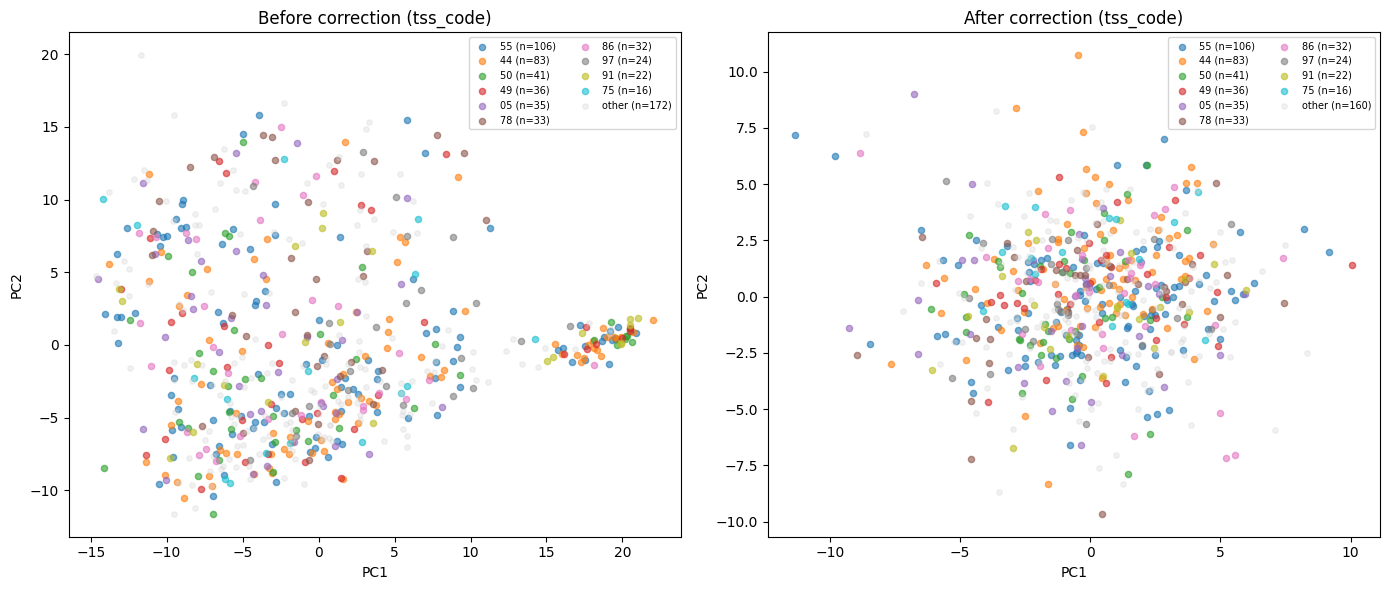

Saved plot to data/results/tcga_pca_before_after.png


In [107]:
#tss_code colored
import matplotlib.pyplot as plt

def _pca_2d(ad):
    work = ad.copy()
    sc.pp.normalize_total(work, target_sum=1e4)
    sc.pp.log1p(work)
    n_hvg = min(2000, work.n_vars - 1)
    sc.pp.highly_variable_genes(work, n_top_genes=n_hvg)
    hvg = work.var['highly_variable'].values
    X = work.X[:, hvg]
    if sparse.issparse(X):
        X = X.toarray()
    return PCA(n_components=2).fit_transform(X)

corrected_adata = tcga_result.get('adata')
if corrected_adata is not None and corrected_adata.n_obs > 10:
    before = _pca_2d(tcga_adata_hvg)
    after = _pca_2d(corrected_adata)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Color map for top tss codes
    from matplotlib.colors import to_hex
    tss_before = tcga_adata_hvg.obs['tss_code'].astype(str).values
    tss_after = corrected_adata.obs['tss_code'].astype(str).values

    top_tss = pd.Series(tss_before).value_counts().head(10).index.tolist()
    palette = plt.cm.tab10(np.linspace(0, 1, len(top_tss)))
    color_map = {t: palette[i] for i, t in enumerate(top_tss)}

    def _plot(ax, coords, labels, title):
        for t in top_tss:
            mask = labels == t
            if mask.sum() == 0:
                continue
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[color_map[t]], label=f'{t} (n={int(mask.sum())})',
                       alpha=0.6, s=20)
        other = ~np.isin(labels, top_tss)
        if other.sum() > 0:
            ax.scatter(coords[other, 0], coords[other, 1],
                       c='lightgray', label=f'other (n={int(other.sum())})',
                       alpha=0.3, s=15)
        ax.set_title(title)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(loc='best', fontsize=7, ncol=2)

    _plot(axes[0], before, tss_before, 'Before correction (tss_code)')
    _plot(axes[1], after, tss_after, 'After correction (tss_code)')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'tcga_pca_before_after.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved plot to {RESULTS_DIR / "tcga_pca_before_after.png"}')
else:
    print('No valid corrected AnnData for PCA plot.')


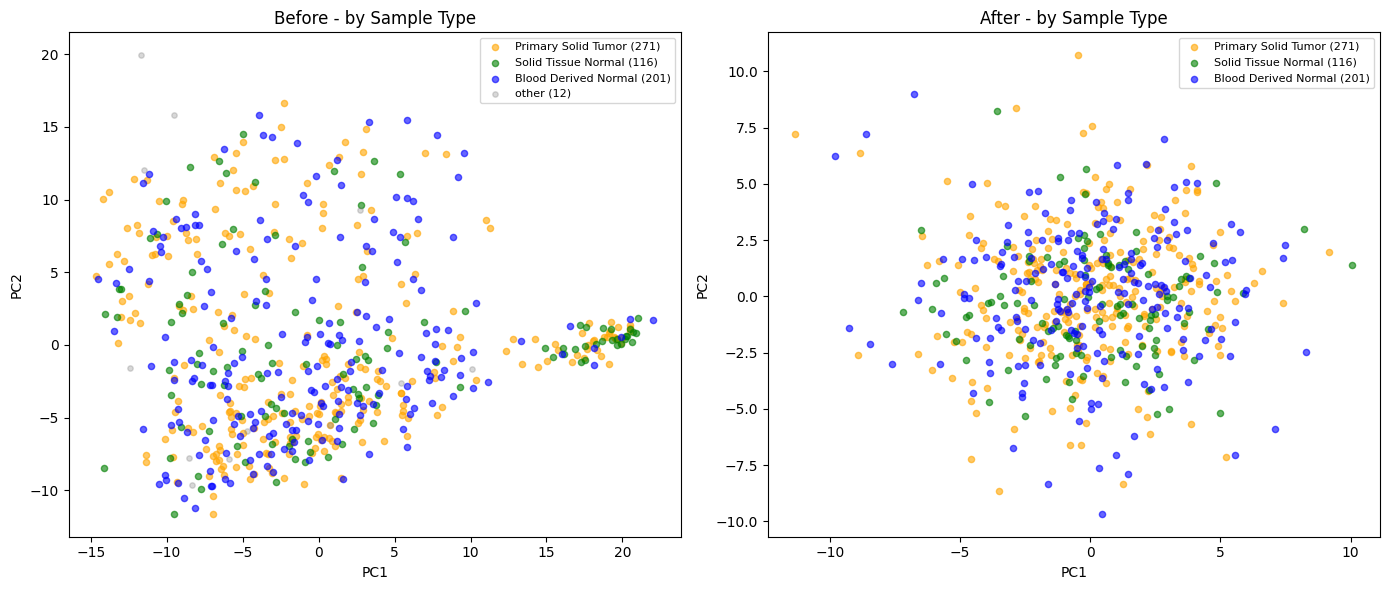

In [108]:
# PCA colored by sample type
if corrected_adata is not None:
    before = _pca_2d(tcga_adata_hvg)
    after = _pca_2d(corrected_adata)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    labels_before = tcga_adata_hvg.obs['sample_type_label'].astype(str).values
    labels_after = corrected_adata.obs['sample_type_label'].astype(str).values

    colors = {'Primary Solid Tumor': 'orange', 'Solid Tissue Normal': 'green',
              'Blood Derived Normal': 'blue'}

    for ax, coords, labels, title in [
        (axes[0], before, labels_before, 'Before - by Sample Type'),
        (axes[1], after, labels_after, 'After - by Sample Type')]:
        for label, color in colors.items():
            mask = labels == label
            if mask.sum() > 0:
                ax.scatter(coords[mask, 0], coords[mask, 1],
                           c=color, label=f'{label} ({mask.sum()})',
                           alpha=0.6, s=20)
        other = ~np.isin(labels, list(colors.keys()))
        if other.sum() > 0:
            ax.scatter(coords[other, 0], coords[other, 1],
                       c='gray', label=f'other ({other.sum()})', alpha=0.3, s=15)
        ax.set_title(title)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'tcga_pca_sample_type.png', dpi=120, bbox_inches='tight')
    plt.show()

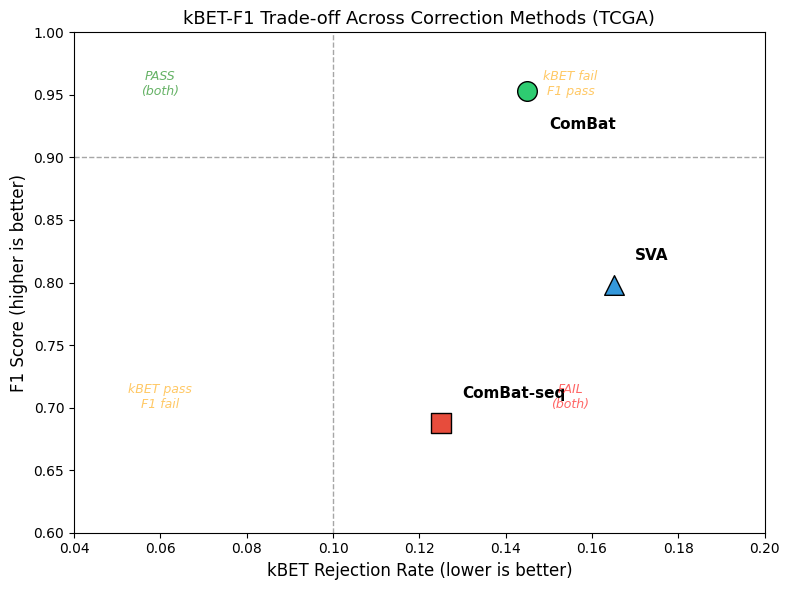

Fig. 5 saved to data/results/fig5_kbet_f1_tradeoff.png


In [111]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

methods = ['ComBat-seq', 'ComBat', 'SVA']
kbet_scores = [0.125, 0.145, 0.165]
f1_scores = [0.688, 0.953, 0.798]
markers = ['s', 'o', '^']  # square, circle, triangle
colors_fig5 = ['#E74C3C', '#2ECC71', '#3498DB']

fig, ax = plt.subplots(figsize=(8, 6))

for i, method in enumerate(methods):
    ax.scatter(kbet_scores[i], f1_scores[i],
               c=colors_fig5[i], marker=markers[i], s=200,
               edgecolors='black', linewidths=1, zorder=5)
    # Label each point
    offset_x = 0.005
    offset_y = 0.02
    if method == 'ComBat':
        offset_y = -0.03
    ax.annotate(method, (kbet_scores[i] + offset_x, f1_scores[i] + offset_y),
                fontsize=11, fontweight='bold')

# Threshold lines
ax.axvline(x=0.10, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=0.90, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Label threshold regions
ax.text(0.06, 0.95, 'PASS\n(both)', fontsize=9, color='green', alpha=0.6,
        ha='center', fontstyle='italic')
ax.text(0.06, 0.70, 'kBET pass\nF1 fail', fontsize=9, color='orange', alpha=0.6,
        ha='center', fontstyle='italic')
ax.text(0.155, 0.95, 'kBET fail\nF1 pass', fontsize=9, color='orange', alpha=0.6,
        ha='center', fontstyle='italic')
ax.text(0.155, 0.70, 'FAIL\n(both)', fontsize=9, color='red', alpha=0.6,
        ha='center', fontstyle='italic')

ax.set_xlabel('kBET Rejection Rate (lower is better)', fontsize=12)
ax.set_ylabel('F1 Score (higher is better)', fontsize=12)
ax.set_title('kBET-F1 Trade-off Across Correction Methods (TCGA)', fontsize=13)

ax.set_xlim(0.04, 0.20)
ax.set_ylim(0.60, 1.00)

plt.tight_layout()
plt.savefig('data/results/fig5_kbet_f1_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig. 5 saved to data/results/fig5_kbet_f1_tradeoff.png')